# Recursive science still-life loop — vision prompts + true FlowMorph midpoints

This local working notebook keeps the useful structure of the recursive vision notebook while making FlowMorph the interpolation mechanism.

1. Edit the anchor sciences and prompts directly in section 2.
2. Generate only the anchor paintings with FLUX.2 Klein and weak previous-anchor continuity.
3. For every cyclic neighbor pair, send both actual paintings, prompts, and science descriptions to the OpenAI vision model. It returns one literal midpoint prompt describing an interdisciplinary and optical middle ground.
4. Prepare one sequence-level FlowMorph model, run one backward probe, and fit every unique image endpoint only once for reuse on both neighboring gaps.
5. Round 1 inserts one explicitly prompted α=0.5 frame per gap. Round 2 inserts ten alpha positions per gap using piecewise source→shared-midpoint→target embedding conditioning. Defaults: 15 anchors → 30 images → 330 images.
6. Finish the duplicate-free cyclic sequence with Practical-RIFE, circular SSIM motion equalization, and H.264 export.

Standalone FLUX generation is never used for recursive midpoint images. Only requested interior alphas are rendered; redundant reconstructed endpoints, per-pair model reloads, per-pair backward probes, LPIPS audits, and pair archives are omitted in this explicit art-production mode. Endpoint checkpoints and pair manifests are written directly into the auto-numbered timestamped Google Drive run directory, so interrupted work can be resumed.


## 1. Editable run, model, API, FlowMorph, image, and video settings

The two rounds intentionally use different schedules. Round 1 makes one explicitly prompted midpoint in each of 15 gaps. Round 2 sees the resulting 30 images, generates one shared interpolation prompt per gap, and renders ten interior alphas while blending conditioning source→midpoint→target. This produces 330 unique images before RIFE while fitting only 30 unique endpoints.

The quality-first defaults use 100 optimization steps per endpoint, keep one model loaded, probe it once, and checkpoint every 25 steps. An optional one-gap quality gate renders before the full recursion, and completed PNGs stream to Drive in small pair chunks during the full run.


In [33]:
PROJECT_ROOT = "/content/FlowMorphKlein9B"
REPOSITORY_URL = "https://github.com/MNoichl/FluxFlowMorph.git"
UPDATE_REPOSITORY = True
PROJECT_NAME = "science_path_recursive_flowmorph"
CONFIG_PATH = f"{PROJECT_ROOT}/configs/full_9b_lora.yaml"
PROFILE = "auto"
LOCAL_ASSET_ROOT = "/content/flowmorph_recursive_art"
HF_CACHE_DIR = "/content/hf_cache"

# Drive and secret. Put only the token text in this file (one line).
MOUNT_DRIVE = True
DRIVE_PROJECT_BASE = "/content/drive/MyDrive/FluxFlowMorphArt"
OPENAI_KEY_FILENAME = "openaiapikey.txt"
RESUME_RUN_DIRECTORY = None  # Example: "/content/drive/MyDrive/FluxFlowMorphArt/science_path_recursive_vision/..."
# RESUME_RUN_DIRECTORY = "/content/drive/MyDrive/FluxFlowMorphArt/science_path_recursive_flowmorph/science_path_recursive_flowmorph_0008_20260722T111308Z"



# OpenAI vision prompt generation.
OPENAI_MODEL = "gpt-5.6"
OPENAI_REASONING_EFFORT = "medium"
OPENAI_IMAGE_DETAIL = "high"  # "low", "high", "original", or "auto"
# Includes hidden reasoning plus visible structured JSON. 5000 avoids
# cutting a valid proposal off in the middle of its prompt string.
OPENAI_MAX_OUTPUT_TOKENS = 5000
OPENAI_MAX_ATTEMPTS = 3
VISION_IMAGE_MAX_SIDE = 1024
VISION_JPEG_QUALITY = 90

# Editable anchor selection and recursive insertion.
BASE_PROMPT_COUNT = 15
FLOWMORPH_ROUND_SPECS = [
    {"midpoint_count": 1, "prompt_mode": "explicit_midpoint"},
    {"midpoint_count": 10, "prompt_mode": "shared_midpoint"},
]
INTERPOLATION_ROUNDS = len(FLOWMORPH_ROUND_SPECS)
REGENERATE_BASE_FRAMES = True
REUSE_EXISTING_MIDPOINTS = True
RESUME_FLOWMORPH_SEQUENCE = True

# Sequence-native true FlowMorph fitting/rendering.
FLOWMORPH_FIT_LORA_SCALE = 1.0
FLOWMORPH_RENDER_LORA_SCALE = 1.0
FLOWMORPH_GUIDANCE_SCALE = 4.0
FLOWMORPH_SCHEDULER_POINTS = 100
FLOWMORPH_START_TIMESTEP_INDEX = 35
FLOWMORPH_SOURCE_OPTIMIZATION_STEPS = 100
FLOWMORPH_TARGET_OPTIMIZATION_STEPS = 100
FLOWMORPH_PRED_LEARNING_RATE = 0.04
FLOWMORPH_U_LEARNING_RATE = 0.01
FLOWMORPH_RENDER_INDICES = [*range(35, 100, 5), 99]
FLOWMORPH_CHECKPOINT_EVERY = 25
FLOWMORPH_STREAM_PAIRS_PER_CHUNK = 3
FLOWMORPH_ENDPOINT_BATCH_SIZE = 2
FLOWMORPH_RENDER_BATCH_SIZE = 4
FLOWMORPH_DECODE_BATCH_SIZE = 8
FLOWMORPH_CFG_EXECUTION = "batched"
FLOWMORPH_BATCH_OOM_BACKOFF = True
OPENAI_CONCURRENCY = 6
FLOWMORPH_STREAM_DISPLAY_PROGRESS = True

# FLUX.2 Klein Base 9B + RIJKSOIL LoRA.
MODEL_ID = "Runware/BFL-FLUX.2-klein-base-9B"
MODEL_REVISION = "52d7274119d8a2b67f4fba1a43694d9169a44851"
LORA_SOURCE = "MaxNoichl/RIJKSOIL_FLUX2_KLEIN9B_lora_01_000001650"
LORA_REVISION = "042a31d6cd09bf55195f820461fac60b1a358409"
LORA_WEIGHT_NAME = "RIJKSOIL_FLUX2_KLEIN9B_lora_01_000001650.safetensors"
LORA_ADAPTER_NAME = "rijks_oil"
LORA_TRIGGER = "RIJKSOIL"

IMAGE_WIDTH = 1024
IMAGE_HEIGHT = 1024
IMAGE_INFERENCE_STEPS = 28
IMAGE_GUIDANCE_SCALE = 4.0
IMAGE_LORA_SCALE = 1.0
BASE_SEED = 98123479812734987 #1729

# Weak continuity applies only to standalone anchor generation.
BASE_CONTINUITY_ENABLED = True
# BASE_REFERENCE_STRENGTH = 0.12
BASE_REFERENCE_STRENGTH = 0.3
BASE_REFERENCE_BLUR = 16.0
BASE_REFERENCE_GRAIN_STRENGTH = 0.035  # Normalized monochrome noise sigma; 0 disables.
REFERENCE_BACKGROUND = (116, 105, 91)
SAVE_SOFT_REFERENCES = True  # Inspect in base_frames/soft_references and its preview sheet.

# Trial and notebook display.
RUN_TRIAL_KEYFRAME = True
TRIAL_KEYFRAME_INDEX = None  # None chooses randomly; otherwise 0..BASE_PROMPT_COUNT-1.
TRIAL_SEED = None
TRIAL_DISPLAY_MAX_WIDTH = 768
RUN_FLOWMORPH_ONE_GAP_TEST = True
FLOWMORPH_ONE_GAP_TEST_INDEX = 0
FLOWMORPH_ONE_GAP_TEST_ALPHAS = [0.25, 0.5, 0.75]
CONTACT_SHEET_COLUMNS = 8
CONTACT_SHEET_DISPLAY_MAX_WIDTH = 1100
LOOP_PREVIEW_DISPLAY_WIDTH = 768
LOOP_PREVIEW_RENDER_MAX_SIDE = 512  # Reduced streaming preview; source PNGs stay untouched.

# Cyclic sequence and RIFE/SSIM finishing.
SOURCE_SEQUENCE_FPS = 12.0
LOOP_AUTO_ROTATE_TO_QUIETEST_CUT = True
LOOP_SEAM_ANALYSIS_SIZE = 192
RUN_RIFE_POSTPROCESS = True
RIFE_REPOSITORY_URL = "https://github.com/hzwer/Practical-RIFE.git"
RIFE_REPOSITORY_REVISION = "17d8c7a1005b37f4c97bfee04e316aaec7fdc536"
RIFE_ROOT = "/content/Practical-RIFE"
RIFE_MODEL_REPOSITORY = "Bash2X/RIFE-Models"
RIFE_MODEL_REVISION = "feaf6d11238b4a1e9f015a5d18c18df152affd20"
RIFE_MODEL_FILENAME = "RIFE_v4.25.zip"
RIFE_MULTIPLIER = 2
RIFE_SCALE = 1.0
RIFE_BATCH_SIZE = 4
RIFE_USE_FP16 = True
RIFE_RETRY_WITH_FP32 = True  # Automatically retry once when the fp16 runner fails.
RIFE_FINAL_FPS = 24.0
RIFE_SSIM_ANALYSIS_SIZE = 192
RIFE_SSIM_WEIGHT_FLOOR = 1e-6
RIFE_VIDEO_CRF = 16
RIFE_KEEP_WORK_FRAMES = False
RIFE_DISPLAY_WIDTH = 768
DOWNLOAD_FINAL_VIDEO = False


## 2. Editable anchor sciences and prompts

Edit these dictionaries directly. `science` is sent to the vision model as conceptual context; `prompt` is sent to FLUX. Every prompt must be a literal visual description and must contain the LoRA trigger `RIJKSOIL`. Avoid production-language such as “bridge frame,” “keep,” “same,” or “transition.”


In [34]:
BASE_STAGES =  [
    {
        "id": "01_astronomy",
        "science": "Astronomy & Astrophysics",
        "prompt": "RIJKSOIL, a hushed Baroque still life of the heavens brought indoors: a tarnished brass armillary sphere and a celestial globe painted with constellations, an astrolabe and a small orrery, bronze dividers resting on a curling star chart, a pitted meteorite and a shard of quartz catching the light. A single candle stands in for a distant sun on black velvet strewn with faint points of starlight. Painted as a Dutch Golden Age pronkstilleven, the candle the only light, deep chiaroscuro over dark velvet and worn stone, a cold indigo-black palette shot with silver starlight and old brass, meticulous oil on panel, glinting glass and tarnished brass, a quiet vanitas hush.",
    },
    {
        "id": "02_nuclear_physics",
        "science": "Nuclear & High-Energy Physics",
        "prompt": "RIJKSOIL, a Baroque still life of matter's hidden fire: a goblet of uranium glass fluorescing eerie green beside a lead casket cracked to show a faintly glowing vial, a gold-leaf electroscope and a brass tuning fork, a cloud chamber where spiral tracks hang like frozen lightning, and a split geode spilling crystalline light. Painted as a Dutch Golden Age pronkstilleven, the candle the only light, deep chiaroscuro over dark velvet and worn stone, a black and lead-grey palette lit by uranium-green fluorescence and one gold spark, meticulous oil on panel, glinting glass and tarnished brass, a quiet vanitas hush.",
    },
    {
        "id": "03_optical_physics",
        "science": "Atomic, Molecular & Optical Physics",
        "prompt": "RIJKSOIL, a jewel-toned Baroque still life of light and the atom: a glass prism splitting the candle's beam into a full spectral ribbon across polished lenses and a brass spectroscope, spectral lines etched on a small plate, soap bubbles filmed with iridescence, and a slab of mother-of-pearl doubling the flame. Painted as a Dutch Golden Age pronkstilleven, the candle the only light, deep chiaroscuro over dark velvet and worn stone, a green flame refracting into a prismatic rainbow against black, meticulous oil on panel, glinting glass and tarnished brass, a quiet vanitas hush.",
    },
    {
        "id": "04_condensed_matter",
        "science": "Electronic, Optical & Magnetic Materials",
        "prompt": "RIJKSOIL, a Baroque still life of ordered matter: a cluster of iridescent bismuth crystals and clear quartz beside a black lodestone dragging iron filings into fine arcs, a polished mirror-bright wafer, a horseshoe magnet, and a small brass model of a crystal lattice. Painted as a Dutch Golden Age pronkstilleven, the candle the only light, deep chiaroscuro over dark velvet and worn stone, iridescent bismuth rainbows cooling into steel-blue and silver, meticulous oil on panel, glinting glass and tarnished brass, a quiet vanitas hush.",
    },
    {
        "id": "05_analytical_chemistry",
        "science": "Materials Chemistry, Spectroscopy & Analytical Chemistry",
        "prompt": "RIJKSOIL, a Baroque still life of assay and flame: a rack of test tubes glowing ruby, cobalt, and amber, a burner flame licked green and copper by unseen salts, a brass spectroscope and a delicate balance scale, reagent bottles with handwritten labels, and curling strips of litmus. Painted as a Dutch Golden Age pronkstilleven, the candle the only light, deep chiaroscuro over dark velvet and worn stone, cool silver warming through copper-flame greens into the first ambers, meticulous oil on panel, glinting glass and tarnished brass, a quiet vanitas hush.",
    },
    {
        "id": "06_organic_chemistry",
        "science": "Organic Chemistry",
        "prompt": "RIJKSOIL, an alchemical Baroque still life of synthesis: a glass alembic and a pear-shaped retort of jewel-coloured liquids, a coiled condenser, a brass ball-and-stick molecule, bundles of dried medicinal plants, a lump of yellow sulphur, and a stone mortar and pestle, candlelit vapours drifting through the dark. Painted as a Dutch Golden Age pronkstilleven, the candle the only light, deep chiaroscuro over dark velvet and worn stone, a deep amber, ruby-glass, and candle-gold palette, meticulous oil on panel, glinting glass and tarnished brass, a quiet vanitas hush.",
    },
    {
        "id": "07_polymers",
        "science": "Polymers, Plastics, Renewable Energy & Green Chemistry",
        "prompt": "RIJKSOIL, a tactile Baroque still life of long chains and living matter: glossy silk cocoons and a spool of unravelling thread, a golden lump of amber with an insect trapped inside, coiled rubber and translucent resin like frozen honey, a scatter of pressed oil-seeds, and a young green leaf beside a small brass mirror turned to the flame. Painted as a Dutch Golden Age pronkstilleven, the candle the only light, deep chiaroscuro over dark velvet and worn stone, honey-amber and translucent gold threaded with young leaf-green, meticulous oil on panel, glinting glass and tarnished brass, a quiet vanitas hush.",
    },
    {
        "id": "08_geosciences",
        "science": "Geosciences: Water, Atmosphere, Geophysics & Planetary Change",
        "prompt": "RIJKSOIL, a Baroque still life of earth and sky: banded agates and mineral specimens, a brass barometer and a glass of layered water and sediment, a small seismograph drum trailing a jagged line, a fossil-bearing rock, and a terrestrial globe half wrapped in drifting mist. Painted as a Dutch Golden Age pronkstilleven, the candle the only light, deep chiaroscuro over dark velvet and worn stone, cool mineral aqua, slate-blue, and misty green, meticulous oil on panel, glinting glass and tarnished brass, a quiet vanitas hush.",
    },
    {
        "id": "09_ecology",
        "science": "Ecology & Environmental Science",
        "prompt": "RIJKSOIL, a mossy Baroque still life of the living web: a bird's nest cradling speckled eggs among ferns and lichened bark, mushrooms and iridescent beetles, a glass of clouded pond water threaded with weed, a butterfly poised mid-flight, and a delicate lattice of twigs and thread, dew glinting in the low light. Painted as a Dutch Golden Age pronkstilleven, the candle the only light, deep chiaroscuro over dark velvet and worn stone, wet forest greens, moss, and dew-silver, meticulous oil on panel, glinting glass and tarnished brass, a quiet vanitas hush.",
    },
    {
        "id": "10_evolution",
        "science": "Evolution, Behavior & Systematics",
        "prompt": "RIJKSOIL, a Baroque still life of deep time: a spiral ammonite and a ridged trilobite half-freed from a broken slab of grey limestone, their coils still embedded in the stone, a fern frond pressed as a dark imprint in split shale, a branching red coral standing for the tree of life, a mounted finch beside cracked seeds and a half-opened chrysalis, a single weathered skull set back in shadow, and an open naturalist's notebook of careful pencil studies. Painted as a Dutch Golden Age pronkstilleven, the candle the only light, deep chiaroscuro over dark velvet and worn stone, fossil grey-green warmed by bone-ochre, meticulous oil on panel, glinting glass and tarnished brass, a quiet vanitas hush.",
    },
    {
        "id": "11_botany",
        "science": "Botany, Plant Science & Food Science",
        "prompt": "RIJKSOIL, an opulent Baroque flower and harvest still life in the manner of Rachel Ruysch: tumbling tulips, roses, and poppies just past their prime, an herbarium sheet with a pinned specimen, a magnifier over a veined leaf, split figs and a broken pomegranate, a sheaf of wheat, and a dark loaf beside a comb of honey. Painted as a Dutch Golden Age pronkstilleven, the candle the only light, deep chiaroscuro over dark velvet and worn stone, verdant leaf-green with ripe fruit-reds and gold, meticulous oil on panel, glinting glass and tarnished brass, a quiet vanitas hush.",
    },
    {
        "id": "12_genetics",
        "science": "Genetics & Molecular Biology",
        "prompt": "RIJKSOIL, a Baroque still life of inheritance: a spiralling pea tendril twisting like a double helix, open pods with sorted green and yellow peas, a small chequered board of crosses, beaded strands laid out like chromosomes, seeds sorted in porcelain dishes, and two miniature family portraits in oval frames. Painted as a Dutch Golden Age pronkstilleven, the candle the only light, deep chiaroscuro over dark velvet and worn stone, warm seed-ochre, parchment, and old gold, meticulous oil on panel, glinting glass and tarnished brass, a quiet vanitas hush.",
    },
    {
        "id": "13_cell_biology",
        "science": "Cell Biology & Microbiology",
        "prompt": "RIJKSOIL, a Baroque still life where every object echoes the cell: a pomegranate split to reveal its packed glistening arils, a fig cut open to its seeded interior, a heaped cluster of translucent gooseberries and glossy fish roe, a comb of honey with rows of hexagonal chambers, and a raft of clustered soap bubbles like living foam, all gathered beside an antique brass microscope whose lens throws a bright disc crowded with round cells caught mid-division. Painted as a Dutch Golden Age pronkstilleven, the candle the only light, deep chiaroscuro over dark velvet and worn stone, pale pearl, milky rose, and soft gold, meticulous oil on panel, glinting glass and tarnished brass, a quiet vanitas hush.",
    },
    {
        "id": "14_immunology",
        "science": "Immunology, Virology & Epidemiology",
        "prompt": "RIJKSOIL, a Baroque still life of contagion and defence: in the foreground a pierced silver pomander packed with dried herbs against the miasma, a curl of bitter cinchona bark, sprigs of rue and rosemary bound with twine, a hand-blown apothecary phial sealed with dark wax and labelled in faded ink, and a small brass-and-ivory bloodletting fleam laid on cold stone. A single fly rests beside a chalked tally on slate while thin smoke drifts from a smouldering censer, and an old beaked plague-doctor's mask of cracked dark leather, its round glass eyes clouded and dim, sits quietly to one side in soft shadow. Painted as a Dutch Golden Age pronkstilleven, the candle the only light, deep chiaroscuro over dark velvet and worn stone, cold pale grey, tarnished silver, and dried sage-green, meticulous oil on panel, glinting glass and tarnished brass, a quiet vanitas hush.",
    },
    {
        "id": "15_pharmacology",
        "science": "Pharmacology, Nutrition & Dietetics",
        "prompt": "RIJKSOIL, an apothecary Baroque still life of remedy: rows of labelled jars holding dried herbs, poppy heads and foxglove and a strip of willow bark, a brass scale weighing pale powders, a pestle mid-grind, a honeycomb and ripe fruit and grain, and an open formulary of handwritten recipes. Painted as a Dutch Golden Age pronkstilleven, the candle the only light, deep chiaroscuro over dark velvet and worn stone, warm apothecary amber, herb-green, and honey, meticulous oil on panel, glinting glass and tarnished brass, a quiet vanitas hush.",
    },
    {
        "id": "16_oncology",
        "science": "Oncology, Hematology & Cancer Research",
        "prompt": "RIJKSOIL, a grave Baroque still life of blood and cell: a stoppered flask of dark crimson beside a vial of drawn blood, a pale crab laid on stone for the old name of the disease, a magnified cluster of dividing cells rendered in glass, a wilting bloom, and surgical steel waiting at the edge of the light. Painted as a Dutch Golden Age pronkstilleven, the candle the only light, deep chiaroscuro over dark velvet and worn stone, deep blood-crimson against black, meticulous oil on panel, glinting glass and tarnished brass, a quiet vanitas hush.",
    },
    {
        "id": "17_surgery_anatomy",
        "science": "Surgery, Anatomy & Cardiology",
        "prompt": "RIJKSOIL, a solemn Baroque anatomical still life: a small écorché figure and a wax model of the human heart, a gleaming scalpel, forceps, and bone-saw, a Vesalian atlas open to an engraved plate, coiled ligatures, a skull, and a serpent twined about a staff. Painted as a Dutch Golden Age pronkstilleven, the candle the only light, deep chiaroscuro over dark velvet and worn stone, carmine flesh, ivory bone, and cold steel, meticulous oil on panel, glinting glass and tarnished brass, a quiet vanitas hush.",
    },
    {
        "id": "18_physiology",
        "science": "Physiology, Endocrinology, Metabolism & Radiology",
        "prompt": "RIJKSOIL, a Baroque still life of the body's inner clock: an hourglass with sand mid-fall, a mercury thermometer and a coiled glass tube, a comb of honey dripping slow for the blood's sweetness, a small anatomical torso opened to show its glands, and a translucent plate glowing faintly like an early radiograph. Painted as a Dutch Golden Age pronkstilleven, the candle the only light, deep chiaroscuro over dark velvet and worn stone, warm honey-flesh cooling toward mercury-silver and X-ray blue, meticulous oil on panel, glinting glass and tarnished brass, a quiet vanitas hush.",
    },
    {
        "id": "19_neurology",
        "science": "Neurology & Cellular/Molecular Neuroscience",
        "prompt": "RIJKSOIL, a Baroque still life of the thinking organ: a human brain suspended in a bell-jar of clear spirit, branching coral and bare winter twigs echoing dendrites, a phrenology bust incised with regions, fine gold filaments, and a faint electric spark leaping a gap. Painted as a Dutch Golden Age pronkstilleven, the candle the only light, deep chiaroscuro over dark velvet and worn stone, electric blue-violet and luminous spirit-clear glass, meticulous oil on panel, glinting glass and tarnished brass, a quiet vanitas hush.",
    },
    {
        "id": "20_cognitive_psychiatry",
        "science": "Cognitive Neuroscience & Psychiatry",
        "prompt": "RIJKSOIL, a Baroque still life of the interior mind: a skull opened to reveal a tiny brass labyrinth, a plate etched with rippling waves like recorded thought, a candle-lit chart of the brain's regions, a slow pendulum, a moth drawn to the flame, and a single inkblot bleeding on parchment. Painted as a Dutch Golden Age pronkstilleven, the candle the only light, deep chiaroscuro over dark velvet and worn stone, deep indigo-violet, dim and uneasy, meticulous oil on panel, glinting glass and tarnished brass, a quiet vanitas hush.",
    },
    {
        "id": "21_psychology",
        "science": "Clinical & Social Psychology",
        "prompt": "RIJKSOIL, a dreamlike Baroque still life of the psyche: a clouded mirror holding a half-lit face, two theatrical masks of comedy and grief, a caged songbird, another inkblot on parchment, a swinging pendulum, and fine threads tying small carved figures together. Painted as a Dutch Golden Age pronkstilleven, the candle the only light, deep chiaroscuro over dark velvet and worn stone, muted blue-grey shadow and tarnished mirror-silver, meticulous oil on panel, glinting glass and tarnished brass, a quiet vanitas hush.",
    },
    {
        "id": "22_philosophy",
        "science": "Philosophy",
        "prompt": "RIJKSOIL, the supreme Baroque vanitas of thought: a skull resting on a stack of worn leather books, a snuffed candle trailing smoke beside a small hand-mirror, an hourglass and a quill in its inkwell, five Platonic solids in glass, an owl in shadow, a compass, and a globe half-turned to the dark. Painted as a Dutch Golden Age pronkstilleven, the candle the only light, deep chiaroscuro over dark velvet and worn stone, warm sepia, candle-gold, and aged leather-brown, meticulous oil on panel, glinting glass and tarnished brass, a quiet vanitas hush.",
    },
    {
        "id": "23_social_sciences",
        "science": "Sociology, Political Science, Economics & Accounting",
        "prompt": "RIJKSOIL, a Baroque still life of society and exchange: brass scales of justice weighing a heap of gold coins against a folded contract, a spilled purse, a merchant's map pricked with dividers, an abacus and an open ledger, ivory dice and playing cards for the games of strategy, a small gavel, and a globe. Painted as a Dutch Golden Age pronkstilleven, the candle the only light, deep chiaroscuro over dark velvet and worn stone, rich coin-gold, ledger-brown, and map-ochre, meticulous oil on panel, glinting glass and tarnished brass, a quiet vanitas hush.",
    },
    {
        "id": "24_computation_math",
        "science": "Computer Science, AI & Mathematics",
        "prompt": "RIJKSOIL, a Baroque still life of pure form and mechanism: an abacus and brass dividers over Euclid's open geometry, interlocking clockwork gears, a chessboard caught mid-game, nested Platonic solids and a small orrery, a perforated brass plate like a punched card, and a single lens turned outward. The candle gutters low, its light circling back toward the stars where the journey began. Painted as a Dutch Golden Age pronkstilleven, the candle the only light, deep chiaroscuro over dark velvet and worn stone, cool brass and silver on black turning toward cosmic indigo, meticulous oil on panel, glinting glass and tarnished brass, a quiet vanitas hush.",
    },
]
 


BASE_PROMPT_COUNT = len(BASE_STAGES)




## 3. GPU, repository, and compatible dependencies

This checks the actual imports needed by the notebook. It does not reject a healthy Diffusers install merely because editable-install provenance metadata is absent. A core reinstall happens only if a clean Python process cannot import the FLUX.2 Klein pipeline and required packages; in that case restart the kernel once after installation.


In [35]:
import platform
import subprocess
import sys
from pathlib import Path

print({"python": sys.version, "platform": platform.platform()})
try:
    import torch
except ImportError as error:
    raise RuntimeError("PyTorch is missing; use a Colab GPU runtime and rerun this cell.") from error
if not torch.cuda.is_available():
    raise RuntimeError("A CUDA GPU runtime is required.")
print({"gpu": torch.cuda.get_device_name(0), "cuda": torch.version.cuda})

project_path = Path(PROJECT_ROOT)
if not (project_path / "pyproject.toml").is_file():
    subprocess.check_call(["git", "clone", "--depth", "1", REPOSITORY_URL, PROJECT_ROOT])
elif UPDATE_REPOSITORY:
    subprocess.check_call(["git", "-C", PROJECT_ROOT, "pull", "--ff-only"])

core_probe = subprocess.run(
    [
        sys.executable,
        "-c",
        "import numpy, scipy, transformers, pydantic; from diffusers import Flux2KleinPipeline",
    ],
    capture_output=True,
    text=True,
)
if core_probe.returncode != 0:
    print("Installing the notebook's pinned FLUX environment because the clean import probe failed:")
    print(core_probe.stderr[-2000:])
    subprocess.check_call([
        sys.executable, "-m", "pip", "install", "-r",
        str(project_path / "requirements-colab.txt"),
    ])
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-e", PROJECT_ROOT])
    raise RuntimeError(
        "Dependencies installed successfully. Restart the notebook kernel once, then rerun from section 1."
    )

try:
    import openai
    from openai import OpenAI
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "openai>=2,<3"])
    import openai
    from openai import OpenAI

import importlib
package_source = str(project_path / "src")
if package_source not in sys.path:
    sys.path.insert(0, package_source)
importlib.invalidate_caches()
import flowmorph_klein
from diffusers import Flux2KleinPipeline

project_commit = subprocess.check_output(
    ["git", "-C", PROJECT_ROOT, "rev-parse", "HEAD"], text=True
).strip()
print({
    "repository_commit": project_commit,
    "flowmorph_source": flowmorph_klein.__file__,
    "openai_sdk": openai.__version__,
})


{'python': '3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]', 'platform': 'Linux-6.6.122+-x86_64-with-glibc2.35'}
{'gpu': 'NVIDIA RTX PRO 6000 Blackwell Server Edition', 'cuda': '12.8'}
{'repository_commit': 'd66c230d2cf844c19bce2396006694c9216780e3', 'flowmorph_source': '/content/FlowMorphKlein9B/src/flowmorph_klein/__init__.py', 'openai_sdk': '2.45.0'}


## 4. Mount Drive, reserve the run directory, and load the API key

Create `openaiapikey.txt` directly inside `DRIVE_PROJECT_BASE`. The file should contain only the API key and a final newline is optional. It is read into the OpenAI client and then the temporary string is deleted. The notebook prints the path it read, never the key or any key fragment.


In [36]:
import json
import re
from datetime import datetime, timezone

if not re.fullmatch(r"[A-Za-z0-9][A-Za-z0-9_-]*", PROJECT_NAME):
    raise ValueError("PROJECT_NAME may contain only letters, numbers, underscores, and hyphens")

DRIVE_ENABLED = False
if MOUNT_DRIVE:
    try:
        from google.colab import drive
    except ImportError as error:
        raise RuntimeError("Drive mounting requires a Google Colab kernel.") from error
    drive.mount("/content/drive")
    drive_base = Path(DRIVE_PROJECT_BASE)
    drive_base.mkdir(parents=True, exist_ok=True)
    DRIVE_ENABLED = True
else:
    drive_base = None

def reserve_numbered_run(parent, project_name):
    project_root = Path(parent) / project_name
    project_root.mkdir(parents=True, exist_ok=True)
    numbers = []
    prefix = f"{project_name}_"
    for candidate in project_root.iterdir():
        if candidate.is_dir() and candidate.name.startswith(prefix):
            token = candidate.name[len(prefix):].split("_", 1)[0]
            if token.isdigit():
                numbers.append(int(token))
    sequence = max(numbers, default=0) + 1
    timestamp = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%SZ")
    while True:
        candidate = project_root / f"{project_name}_{sequence:04d}_{timestamp}"
        try:
            candidate.mkdir(parents=False, exist_ok=False)
        except FileExistsError:
            sequence += 1
            continue
        return candidate

if RESUME_RUN_DIRECTORY is not None:
    RUN_DIRECTORY = Path(RESUME_RUN_DIRECTORY).expanduser()
    if not RUN_DIRECTORY.is_dir():
        raise FileNotFoundError(f"RESUME_RUN_DIRECTORY does not exist: {RUN_DIRECTORY}")
elif DRIVE_ENABLED:
    RUN_DIRECTORY = reserve_numbered_run(drive_base, PROJECT_NAME)
else:
    RUN_DIRECTORY = reserve_numbered_run(LOCAL_ASSET_ROOT, PROJECT_NAME)

for child in ("base_frames", "trials", "rounds", "previews", "video", "metadata"):
    (RUN_DIRECTORY / child).mkdir(parents=True, exist_ok=True)
Path(HF_CACHE_DIR).mkdir(parents=True, exist_ok=True)

if not DRIVE_ENABLED:
    raise RuntimeError(
        "This notebook's OpenAI key workflow expects Google Drive. Set MOUNT_DRIVE=True."
    )
OPENAI_KEY_PATH = drive_base / OPENAI_KEY_FILENAME
if not OPENAI_KEY_PATH.is_file():
    raise FileNotFoundError(
        f"Create {OPENAI_KEY_PATH} with only your OpenAI API key, then rerun this cell."
    )
_openai_key = OPENAI_KEY_PATH.read_text(encoding="utf-8").strip()
if len(_openai_key) < 20 or any(character.isspace() for character in _openai_key):
    raise ValueError("The Drive key file is empty or malformed; expected one token with no spaces.")
OPENAI_CLIENT = OpenAI(api_key=_openai_key)
del _openai_key

run_identity = {
    "project": PROJECT_NAME,
    "created_utc": datetime.now(timezone.utc).isoformat(),
    "persistent": DRIVE_ENABLED,
    "run_directory": str(RUN_DIRECTORY),
    "openai_model": OPENAI_MODEL,
    "key_file": str(OPENAI_KEY_PATH),
    "key_value_recorded": False,
}
(RUN_DIRECTORY / "metadata" / "run_identity.json").write_text(
    json.dumps(run_identity, indent=2, ensure_ascii=False) + "\n", encoding="utf-8"
)
print("OpenAI client initialized from the Drive key file (credential value not displayed).")
print("Run directory:", RUN_DIRECTORY)
print("Every generated image and manifest is written directly into this persistent directory.")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
OpenAI client initialized from the Drive key file (credential value not displayed).
Run directory: /content/drive/MyDrive/FluxFlowMorphArt/science_path_recursive_flowmorph/science_path_recursive_flowmorph_0019_20260722T214001Z
Every generated image and manifest is written directly into this persistent directory.


## 5. Validate settings and preview the recursive cost

The validation also catches accidental missing or duplicated LoRA triggers in anchor prompts. It does not rewrite your text.


In [37]:
if not 3 <= BASE_PROMPT_COUNT <= len(BASE_STAGES):
    raise ValueError(f"BASE_PROMPT_COUNT must be between 3 and {len(BASE_STAGES)}")
if len(FLOWMORPH_ROUND_SPECS) != 2:
    raise ValueError("This notebook expects exactly two FlowMorph rounds")
allowed_prompt_modes = {"explicit_midpoint", "shared_midpoint"}
for index, spec in enumerate(FLOWMORPH_ROUND_SPECS, start=1):
    if spec.get("prompt_mode") not in allowed_prompt_modes:
        raise ValueError(f"Invalid prompt mode in round {index}: {spec}")
    if not 1 <= int(spec.get("midpoint_count", 0)) <= 20:
        raise ValueError(f"Round {index} midpoint_count must be between 1 and 20")
if FLOWMORPH_ROUND_SPECS[0] != {"midpoint_count": 1, "prompt_mode": "explicit_midpoint"}:
    raise ValueError("Round 1 must use one explicitly prompted midpoint")
if FLOWMORPH_ROUND_SPECS[1] != {"midpoint_count": 10, "prompt_mode": "shared_midpoint"}:
    raise ValueError("Round 2 must use ten renders sharing one interpolation prompt")
if not (256 <= IMAGE_WIDTH <= 2048 and IMAGE_WIDTH % 16 == 0):
    raise ValueError("IMAGE_WIDTH must be 256–2048 and divisible by 16")
if not (256 <= IMAGE_HEIGHT <= 2048 and IMAGE_HEIGHT % 16 == 0):
    raise ValueError("IMAGE_HEIGHT must be 256–2048 and divisible by 16")
if not 1 <= IMAGE_INFERENCE_STEPS <= 100:
    raise ValueError("IMAGE_INFERENCE_STEPS must be between 1 and 100")
if not 0 <= IMAGE_GUIDANCE_SCALE <= 20:
    raise ValueError("IMAGE_GUIDANCE_SCALE must be between 0 and 20")
if not 0 < IMAGE_LORA_SCALE <= 4:
    raise ValueError("IMAGE_LORA_SCALE must lie in (0, 4]")
if not 0 < BASE_REFERENCE_STRENGTH <= 1.0:
    raise ValueError("BASE_REFERENCE_STRENGTH must lie in (0, 1]")
if not 0 <= BASE_REFERENCE_GRAIN_STRENGTH <= 0.25:
    raise ValueError("BASE_REFERENCE_GRAIN_STRENGTH must lie in [0, 0.25]")
if OPENAI_IMAGE_DETAIL not in {"low", "high", "original", "auto"}:
    raise ValueError("OPENAI_IMAGE_DETAIL must be low, high, original, or auto")
if FLOWMORPH_START_TIMESTEP_INDEX != FLOWMORPH_RENDER_INDICES[0]:
    raise ValueError("The first render index must equal the FlowMorph start index")
if FLOWMORPH_RENDER_INDICES != sorted(set(FLOWMORPH_RENDER_INDICES)):
    raise ValueError("FLOWMORPH_RENDER_INDICES must be strictly increasing")
if FLOWMORPH_RENDER_INDICES[-1] >= FLOWMORPH_SCHEDULER_POINTS:
    raise ValueError("FLOWMORPH_RENDER_INDICES must be smaller than scheduler points")
if FLOWMORPH_SOURCE_OPTIMIZATION_STEPS != FLOWMORPH_TARGET_OPTIMIZATION_STEPS:
    raise ValueError("Sequence-cached endpoints require one shared optimization-step count")
if FLOWMORPH_SOURCE_OPTIMIZATION_STEPS < 1:
    raise ValueError("FlowMorph optimization steps must be positive")
if FLOWMORPH_SOURCE_OPTIMIZATION_STEPS != 100:
    raise ValueError("This quality-first notebook requires 100 endpoint fitting steps")
if FLOWMORPH_FIT_LORA_SCALE != IMAGE_LORA_SCALE:
    raise ValueError("FlowMorph fit LoRA scale must match IMAGE_LORA_SCALE")
if FLOWMORPH_RENDER_LORA_SCALE != IMAGE_LORA_SCALE:
    raise ValueError("FlowMorph render LoRA scale must match IMAGE_LORA_SCALE")
if FLOWMORPH_GUIDANCE_SCALE != IMAGE_GUIDANCE_SCALE:
    raise ValueError("FlowMorph guidance must match IMAGE_GUIDANCE_SCALE")
if FLOWMORPH_STREAM_PAIRS_PER_CHUNK < 1:
    raise ValueError("FLOWMORPH_STREAM_PAIRS_PER_CHUNK must be positive")
for name, value in {
    "FLOWMORPH_ENDPOINT_BATCH_SIZE": FLOWMORPH_ENDPOINT_BATCH_SIZE,
    "FLOWMORPH_RENDER_BATCH_SIZE": FLOWMORPH_RENDER_BATCH_SIZE,
    "FLOWMORPH_DECODE_BATCH_SIZE": FLOWMORPH_DECODE_BATCH_SIZE,
    "OPENAI_CONCURRENCY": OPENAI_CONCURRENCY,
}.items():
    if value < 1:
        raise ValueError(f"{name} must be positive")
if FLOWMORPH_CFG_EXECUTION not in {"sequential", "batched"}:
    raise ValueError("FLOWMORPH_CFG_EXECUTION must be sequential or batched")
if not 0 <= FLOWMORPH_ONE_GAP_TEST_INDEX < BASE_PROMPT_COUNT:
    raise ValueError("FLOWMORPH_ONE_GAP_TEST_INDEX is outside the active anchor range")
if (
    not FLOWMORPH_ONE_GAP_TEST_ALPHAS
    or FLOWMORPH_ONE_GAP_TEST_ALPHAS != sorted(set(FLOWMORPH_ONE_GAP_TEST_ALPHAS))
    or any(not 0.0 < alpha < 1.0 for alpha in FLOWMORPH_ONE_GAP_TEST_ALPHAS)
):
    raise ValueError("FLOWMORPH_ONE_GAP_TEST_ALPHAS must be unique sorted interior values")

ACTIVE_BASE_STAGES = BASE_STAGES[:BASE_PROMPT_COUNT]
ids = [item["id"] for item in ACTIVE_BASE_STAGES]
if len(ids) != len(set(ids)) or any(not re.fullmatch(r"[a-z0-9_]+", item) for item in ids):
    raise ValueError("Anchor IDs must be unique lowercase snake_case values")
for item in ACTIVE_BASE_STAGES:
    if not item["science"].strip() or not item["prompt"].strip():
        raise ValueError(f"Blank science or prompt in {item['id']}")
    if item["prompt"].casefold().count(LORA_TRIGGER.casefold()) != 1:
        raise ValueError(f"{item['id']} must contain the LoRA trigger exactly once")

round_counts = [BASE_PROMPT_COUNT]
for spec in FLOWMORPH_ROUND_SPECS:
    round_counts.append(round_counts[-1] * (int(spec["midpoint_count"]) + 1))
pair_renders = sum(round_counts[:-1])
openai_calls = pair_renders  # One image-aware prompt per gap in both modes.
unique_endpoint_fits = round_counts[-2]
print({
    "anchor_images": BASE_PROMPT_COUNT,
    "sequence_counts": round_counts,
    "openai_vision_calls": openai_calls,
    "sequence_pair_renders": pair_renders,
    "unique_endpoint_fits": unique_endpoint_fits,
    "final_generated_sequence_images": round_counts[-1],
    "round_specs": FLOWMORPH_ROUND_SPECS,
    "rife_multiplier": RIFE_MULTIPLIER,
})
print("Anchor order:", " → ".join(ids), "→", ids[0])


{'anchor_images': 24, 'sequence_counts': [24, 48, 528], 'openai_vision_calls': 72, 'sequence_pair_renders': 72, 'unique_endpoint_fits': 48, 'final_generated_sequence_images': 528, 'round_specs': [{'midpoint_count': 1, 'prompt_mode': 'explicit_midpoint'}, {'midpoint_count': 10, 'prompt_mode': 'shared_midpoint'}], 'rife_multiplier': 2}
Anchor order: 01_astronomy → 02_nuclear_physics → 03_optical_physics → 04_condensed_matter → 05_analytical_chemistry → 06_organic_chemistry → 07_polymers → 08_geosciences → 09_ecology → 10_evolution → 11_botany → 12_genetics → 13_cell_biology → 14_immunology → 15_pharmacology → 16_oncology → 17_surgery_anatomy → 18_physiology → 19_neurology → 20_cognitive_psychiatry → 21_psychology → 22_philosophy → 23_social_sciences → 24_computation_math → 01_astronomy


## 6. Load and fuse the RIJKSOIL LoRA; optional generation and FlowMorph tests

The first optional trial checks standalone anchor-generation settings. The one-gap FlowMorph quality gate is configured beside it, then runs at the start of section 9 after two real anchor images exist and the reusable FlowMorph model has loaded. It displays and saves `source | α=.25 | α=.5 | α=.75 | target` before the full recursive cell is run.


Reusing the fused pipeline at the current LoRA scale.


  0%|          | 0/28 [00:00<?, ?it/s]

### Trial anchor: `03_optical_physics`

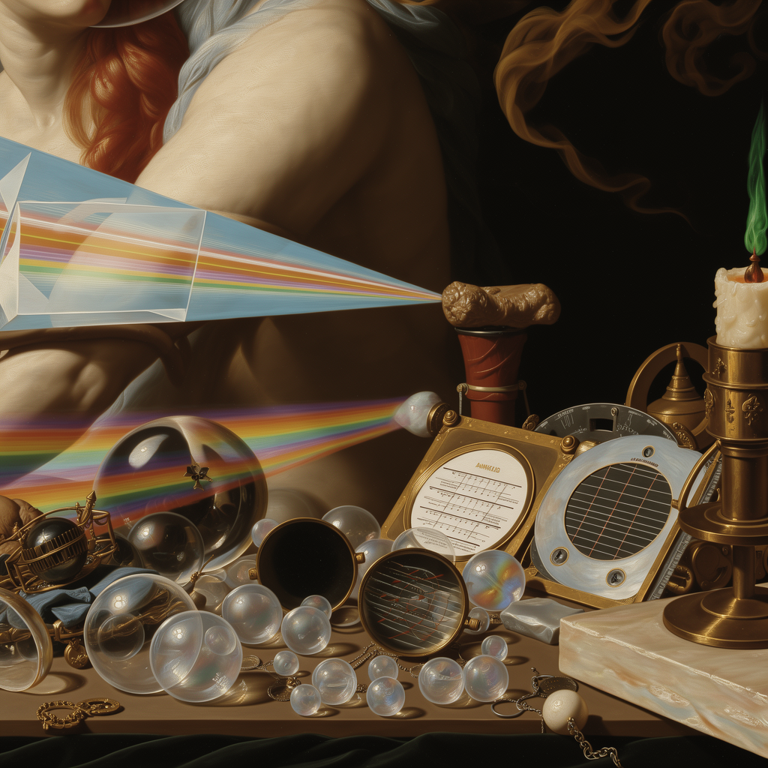

{'path': '/content/drive/MyDrive/FluxFlowMorphArt/science_path_recursive_flowmorph/science_path_recursive_flowmorph_0019_20260722T214001Z/trials/20260722T214026Z_03_optical_physics_1036611447/trial.png', 'seed': 1036611447, 'prompt_index': 2}


In [38]:
import gc
import os
import random
import shutil
from huggingface_hub import hf_hub_download
from IPython.display import Markdown, display
from PIL import Image, ImageFilter
from flowmorph_klein.lora import load_flux2_lora

try:
    import peft.tuners.lora.torchao as peft_torchao_dispatch
except ImportError:
    peft_torchao_dispatch = None
else:
    peft_torchao_dispatch.is_torchao_available = lambda: False

downloaded_lora = Path(hf_hub_download(
    repo_id=LORA_SOURCE,
    filename=LORA_WEIGHT_NAME,
    revision=LORA_REVISION,
    cache_dir=HF_CACHE_DIR,
))
lora_stage_directory = Path(HF_CACHE_DIR) / "flowmorph_lora_files" / LORA_REVISION[:12]
lora_stage_directory.mkdir(parents=True, exist_ok=True)
LOCAL_LORA_PATH = lora_stage_directory / LORA_WEIGHT_NAME
if not LOCAL_LORA_PATH.is_file():
    try:
        os.link(downloaded_lora.resolve(), LOCAL_LORA_PATH)
    except OSError:
        shutil.copy2(downloaded_lora, LOCAL_LORA_PATH)
if LOCAL_LORA_PATH.stat().st_size != downloaded_lora.stat().st_size:
    raise RuntimeError(f"Staged LoRA size mismatch at {LOCAL_LORA_PATH}")

def release_flux_pipeline():
    previous = globals().pop("FLUX_PIPE", None)
    globals().pop("FLUX_PIPE_LORA_SCALE", None)
    if previous is not None:
        maybe_free = getattr(previous, "maybe_free_model_hooks", None)
        if callable(maybe_free):
            maybe_free()
        del previous
        gc.collect()
        torch.cuda.empty_cache()

def load_flux_pipeline():
    pipeline = Flux2KleinPipeline.from_pretrained(
        MODEL_ID,
        revision=MODEL_REVISION,
        cache_dir=HF_CACHE_DIR,
        torch_dtype=torch.bfloat16,
        low_cpu_mem_usage=True,
    )
    report = load_flux2_lora(
        pipeline,
        str(LOCAL_LORA_PATH),
        adapter_name=LORA_ADAPTER_NAME,
        scale=IMAGE_LORA_SCALE,
        require_base_9b_provenance=False,
        allow_distilled_9b=True,
    )
    pipeline.fuse_lora(
        components=["transformer"],
        lora_scale=1.0,
        safe_fusing=True,
        adapter_names=[LORA_ADAPTER_NAME],
    )
    pipeline.unload_lora_weights()
    remaining = [
        name for name, _ in pipeline.transformer.named_parameters()
        if "lora_" in name.casefold() or ".lora" in name.casefold()
    ]
    if remaining:
        raise RuntimeError("LoRA fusion left runtime parameters: " + ", ".join(remaining[:5]))
    pipeline.enable_model_cpu_offload()
    pipeline.vae.enable_slicing()
    pipeline.vae.enable_tiling()
    return pipeline, report

if "FLUX_PIPE" in globals() and globals().get("FLUX_PIPE_LORA_SCALE") != float(IMAGE_LORA_SCALE):
    print("LoRA scale changed; rebuilding the fused pipeline.")
    release_flux_pipeline()
if "FLUX_PIPE" not in globals():
    FLUX_PIPE, LORA_REPORT = load_flux_pipeline()
    FLUX_PIPE_LORA_SCALE = float(IMAGE_LORA_SCALE)
    print("Loaded a device-safe fused-LoRA pipeline.")
else:
    print("Reusing the fused pipeline at the current LoRA scale.")

if RUN_TRIAL_KEYFRAME:
    system_random = random.SystemRandom()
    trial_index = (
        TRIAL_KEYFRAME_INDEX
        if TRIAL_KEYFRAME_INDEX is not None
        else system_random.randrange(len(ACTIVE_BASE_STAGES))
    )
    if not 0 <= trial_index < len(ACTIVE_BASE_STAGES):
        raise IndexError("TRIAL_KEYFRAME_INDEX is outside the active anchor range")
    trial_seed = TRIAL_SEED if TRIAL_SEED is not None else system_random.randrange(2**31)
    trial_stage = ACTIVE_BASE_STAGES[trial_index]
    trial_result = FLUX_PIPE(
        prompt=trial_stage["prompt"],
        height=IMAGE_HEIGHT,
        width=IMAGE_WIDTH,
        num_inference_steps=IMAGE_INFERENCE_STEPS,
        guidance_scale=IMAGE_GUIDANCE_SCALE,
        generator=torch.Generator(device="cuda").manual_seed(trial_seed),
        output_type="pil",
    )
    trial_image = trial_result.images[0].convert("RGB")
    trial_stamp = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%SZ")
    trial_directory = RUN_DIRECTORY / "trials" / f"{trial_stamp}_{trial_stage['id']}_{trial_seed}"
    trial_directory.mkdir(parents=True, exist_ok=False)
    trial_path = trial_directory / "trial.png"
    trial_image.save(trial_path)
    (trial_directory / "settings.json").write_text(json.dumps({
        "stage": trial_stage,
        "seed": trial_seed,
        "lora_scale": IMAGE_LORA_SCALE,
        "guidance_scale": IMAGE_GUIDANCE_SCALE,
        "inference_steps": IMAGE_INFERENCE_STEPS,
        "size": [IMAGE_WIDTH, IMAGE_HEIGHT],
    }, indent=2, ensure_ascii=False) + "\n", encoding="utf-8")
    preview = trial_image.copy()
    preview.thumbnail((TRIAL_DISPLAY_MAX_WIDTH, TRIAL_DISPLAY_MAX_WIDTH))
    display(Markdown(f"### Trial anchor: `{trial_stage['id']}`"))
    display(preview)
    print({"path": str(trial_path), "seed": trial_seed, "prompt_index": trial_index})
    del trial_result, trial_image, preview
else:
    print("Trial skipped.")


## 7. Generate the cyclic anchor paintings

The first anchor is text-to-image. Later anchors receive only a faint blurred trace of the previous anchor. Images are not individually displayed; the following cell renders one compact contact sheet.


In [39]:
from flowmorph_klein.art_loop import make_soft_reference

BASE_DIRECTORY = RUN_DIRECTORY / "base_frames"
BASE_MANIFEST_PATH = RUN_DIRECTORY / "metadata" / "base_manifest.json"
BASE_RECORDS = []

if not REGENERATE_BASE_FRAMES and BASE_MANIFEST_PATH.is_file():
    BASE_RECORDS = json.loads(BASE_MANIFEST_PATH.read_text(encoding="utf-8"))["records"]
    missing = [item["path"] for item in BASE_RECORDS if not Path(item["path"]).is_file()]
    if missing:
        raise FileNotFoundError("Missing resumed anchor images: " + ", ".join(missing))
    resumed_contract = [
        (record["uid"], record["science"], record["prompt"])
        for record in BASE_RECORDS
    ]
    current_contract = [
        (f"base_{index:03d}", stage["science"], stage["prompt"])
        for index, stage in enumerate(ACTIVE_BASE_STAGES)
    ]
    if resumed_contract != current_contract:
        raise RuntimeError(
            "The editable anchor prompts differ from this run's saved anchors. "
            "Set REGENERATE_BASE_FRAMES=True or resume the matching notebook settings."
        )
    print(f"Loaded {len(BASE_RECORDS)} existing anchor records.")
else:
    previous = None
    for index, stage in enumerate(ACTIVE_BASE_STAGES):
        seed = BASE_SEED + index
        kwargs = {
            "prompt": stage["prompt"],
            "height": IMAGE_HEIGHT,
            "width": IMAGE_WIDTH,
            "num_inference_steps": IMAGE_INFERENCE_STEPS,
            "guidance_scale": IMAGE_GUIDANCE_SCALE,
            "generator": torch.Generator(device="cuda").manual_seed(seed),
            "output_type": "pil",
        }
        reference_path = None
        if previous is not None and BASE_CONTINUITY_ENABLED:
            reference = make_soft_reference(
                previous,
                reference_blend=BASE_REFERENCE_STRENGTH,
                blur_radius=BASE_REFERENCE_BLUR,
                grain_strength=BASE_REFERENCE_GRAIN_STRENGTH,
                grain_seed=seed,
                background_rgb=REFERENCE_BACKGROUND,
            )
            kwargs["image"] = reference
            if SAVE_SOFT_REFERENCES:
                reference_directory = BASE_DIRECTORY / "soft_references"
                reference_directory.mkdir(parents=True, exist_ok=True)
                reference_path = reference_directory / f"reference_{index:03d}.png"
                reference.save(reference_path)
        result = FLUX_PIPE(**kwargs)
        if not result.images:
            raise RuntimeError(f"FLUX returned no image for {stage['id']}")
        image = result.images[0].convert("RGB")
        output_path = BASE_DIRECTORY / f"{index:03d}_{stage['id']}.png"
        image.save(output_path, compress_level=4)
        record = {
            "uid": f"base_{index:03d}",
            "kind": "base",
            "round": 0,
            "science": stage["science"],
            "prompt": stage["prompt"],
            "seed": seed,
            "path": str(output_path),
            "soft_reference_path": str(reference_path) if reference_path else None,
            "soft_reference_grain_strength": BASE_REFERENCE_GRAIN_STRENGTH,
            "soft_reference_grain_seed": seed if previous is not None else None,
        }
        BASE_RECORDS.append(record)
        BASE_MANIFEST_PATH.write_text(json.dumps({
            "records": BASE_RECORDS,
            "complete": len(BASE_RECORDS) == len(ACTIVE_BASE_STAGES),
        }, indent=2, ensure_ascii=False) + "\n", encoding="utf-8")
        previous = image
        print(f"Anchor {index + 1}/{len(ACTIVE_BASE_STAGES)} saved: {output_path.name}")
        del result
    del previous

if len(BASE_RECORDS) != len(ACTIVE_BASE_STAGES):
    raise RuntimeError("The anchor manifest is incomplete; regenerate or select the correct resume run.")
print(f"Prepared {len(BASE_RECORDS)} cyclic anchors in {BASE_DIRECTORY}")


  0%|          | 0/28 [00:00<?, ?it/s]

Anchor 1/24 saved: 000_01_astronomy.png


  0%|          | 0/28 [00:00<?, ?it/s]

Anchor 2/24 saved: 001_02_nuclear_physics.png


  0%|          | 0/28 [00:00<?, ?it/s]

...

Anchor 22/24 saved: 021_22_philosophy.png


  0%|          | 0/28 [00:00<?, ?it/s]

Anchor 23/24 saved: 022_23_social_sciences.png


  0%|          | 0/28 [00:00<?, ?it/s]

Anchor 24/24 saved: 023_24_computation_math.png
Prepared 24 cyclic anchors in /content/drive/MyDrive/FluxFlowMorphArt/science_path_recursive_flowmorph/science_path_recursive_flowmorph_0019_20260722T214001Z/base_frames


### Anchor paintings — compact contact sheet

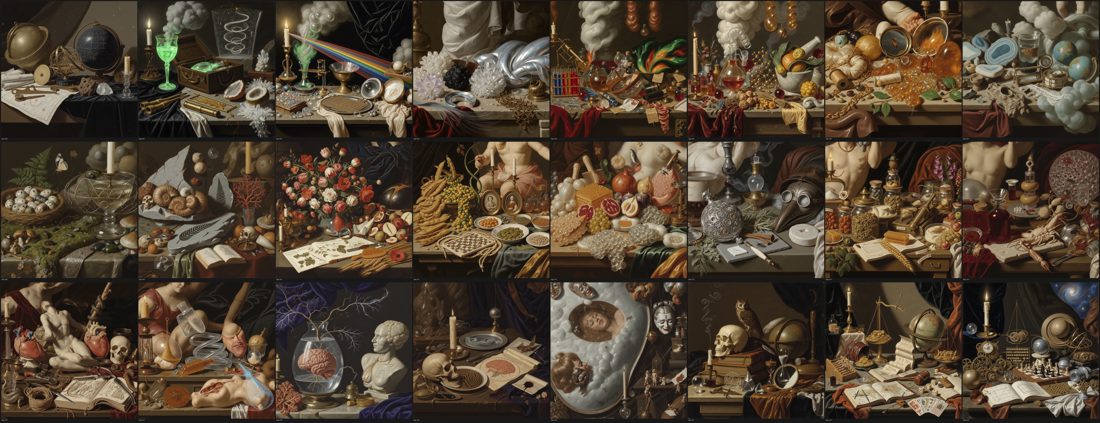

Full-resolution anchors and contact sheet: /content/drive/MyDrive/FluxFlowMorphArt/science_path_recursive_flowmorph/science_path_recursive_flowmorph_0019_20260722T214001Z/base_frames


### Blurred/grained anchor initialization images

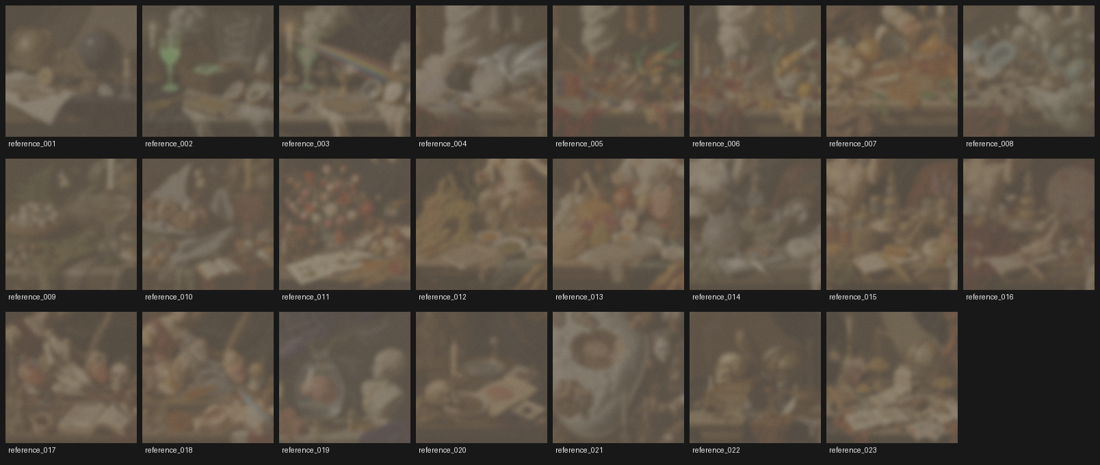

Full-resolution anchor initialization images: /content/drive/MyDrive/FluxFlowMorphArt/science_path_recursive_flowmorph/science_path_recursive_flowmorph_0019_20260722T214001Z/base_frames/soft_references


In [40]:
from flowmorph_klein.visualization import make_contact_sheet

base_contact_sheet_path = RUN_DIRECTORY / "previews" / "base_contact_sheet.png"
base_images = [Image.open(item["path"]).convert("RGB") for item in BASE_RECORDS]
make_contact_sheet(
    base_images,
    base_contact_sheet_path,
    columns=min(CONTACT_SHEET_COLUMNS, len(base_images)),
    labels=[item["uid"] for item in BASE_RECORDS],
)
for image in base_images:
    image.close()
base_preview = Image.open(base_contact_sheet_path).convert("RGB")
base_preview.thumbnail((CONTACT_SHEET_DISPLAY_MAX_WIDTH, 100000))
display(Markdown("### Anchor paintings — compact contact sheet"))
display(base_preview)
del base_preview, base_images
print("Full-resolution anchors and contact sheet:", BASE_DIRECTORY)

saved_reference_paths = [
    Path(item["soft_reference_path"])
    for item in BASE_RECORDS
    if item.get("soft_reference_path") and Path(item["soft_reference_path"]).is_file()
]
if saved_reference_paths:
    reference_contact_sheet_path = (
        RUN_DIRECTORY / "previews" / "anchor_soft_reference_contact_sheet.png"
    )
    reference_images = []
    for path in saved_reference_paths:
        with Image.open(path) as opened:
            thumbnail = opened.convert("RGB")
            thumbnail.thumbnail((192, 192))
            reference_images.append(thumbnail)
    make_contact_sheet(
        reference_images,
        reference_contact_sheet_path,
        columns=min(CONTACT_SHEET_COLUMNS, len(reference_images)),
        labels=[path.stem for path in saved_reference_paths],
    )
    for image in reference_images:
        image.close()
    reference_preview = Image.open(reference_contact_sheet_path).convert("RGB")
    reference_preview.thumbnail((CONTACT_SHEET_DISPLAY_MAX_WIDTH, 100000))
    display(Markdown("### Blurred/grained anchor initialization images"))
    display(reference_preview)
    reference_preview.close()
    print("Full-resolution anchor initialization images:", saved_reference_paths[0].parent)


## 8. Define the image-aware midpoint prompt contract

Each API call receives both actual endpoint images, both literal prompts, both science descriptions, and the requested fractional position. The model returns structured fields, but only its standalone descriptive `prompt` is sent to FLUX. Explanatory fields are saved for audit.

Semantic validation rejects common failure modes from the earlier hand-authored JSONs: production jargon, instructions to keep things “the same,” and missing/duplicated LoRA triggers. Failed semantic outputs are retried with a concise correction.


In [19]:
import base64
import hashlib
import io
import time
from pydantic import BaseModel, Field, ValidationError

class MidpointProposal(BaseModel):
    science_connection: str = Field(min_length=20, max_length=800)
    visual_correspondence: str = Field(min_length=20, max_length=1200)
    prompt: str = Field(min_length=300, max_length=2600)

MIDPOINT_SYSTEM_PROMPT = f"""
Role: You are an art director writing one prompt for FLUX.2 Klein with the {LORA_TRIGGER} oil-painting LoRA.

Goal: Given two endpoint still-life paintings, their prompts, and their science descriptions, write the literal visual description of a painting at the requested fractional position from A to B. It must be a plausible interdisciplinary scientific still life and a genuine visual midpoint.

Success criteria:
- Inspect both images, not merely their text. Map major objects by position, silhouette, scale, orientation, material, color, lighting, negative space, and support geometry.
- Transform each important correspondence by one small intelligible step. A vessel may change proportion/material/content toward the paired object; folds, arcs, lenses, coils, branches, handles, bowls, organs, instruments, and shadows may become thematically appropriate intermediate forms.
- Connect the named sciences with concrete objects or processes. Do not invent a third unrelated scene.
- Produce one self-contained descriptive image prompt. Repeat every visual fact that should appear; do not refer back to either endpoint.
- Preserve the established medium-wide seventeenth-century Dutch Baroque still-life language, theatrical chiaroscuro, material specificity, layered oil glazes, restrained impasto, no people, and no readable text.
- The prompt begins exactly with "{LORA_TRIGGER}," and contains that trigger exactly once.

Prompt prohibitions: Do not use the words bridge, transition, intermediate, halfway, keep, retain, preserve, unchanged, same, source image, target image, left image, right image, endpoint, frame, interpolation, or morph. Do not issue editing commands. Do not introduce generic walnut tables or other stock furniture unless the visible supports in both images justify it.

Output: science_connection briefly states the interdisciplinary logic; visual_correspondence briefly states the concrete A-to-B object and composition mappings; prompt contains only the final literal image description.
""".strip()

FORBIDDEN_PROMPT_TERMS = (
    "bridge", "transition", "intermediate", "halfway", "keep", "retain", "preserve",
    "unchanged", "same", "source image", "target image", "left image", "right image",
    "endpoint", "frame", "interpolation", "morph",
)

def image_data_url(path):
    with Image.open(path) as opened:
        image = opened.convert("RGB")
        image.thumbnail((VISION_IMAGE_MAX_SIDE, VISION_IMAGE_MAX_SIDE))
        buffer = io.BytesIO()
        image.save(buffer, format="JPEG", quality=VISION_JPEG_QUALITY, optimize=True)
    encoded = base64.b64encode(buffer.getvalue()).decode("ascii")
    return f"data:image/jpeg;base64,{encoded}"

def file_sha256(path):
    digest = hashlib.sha256()
    with Path(path).open("rb") as handle:
        for chunk in iter(lambda: handle.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()

def midpoint_request_fingerprint(left, right, fraction):
    contract = {
        "model": OPENAI_MODEL,
        "reasoning_effort": OPENAI_REASONING_EFFORT,
        "image_detail": OPENAI_IMAGE_DETAIL,
        "system_prompt": MIDPOINT_SYSTEM_PROMPT,
        "fraction": fraction,
        "left_uid": left["uid"],
        "left_science": left["science"],
        "left_prompt": left["prompt"],
        "left_image_sha256": file_sha256(left["path"]),
        "right_uid": right["uid"],
        "right_science": right["science"],
        "right_prompt": right["prompt"],
        "right_image_sha256": file_sha256(right["path"]),
    }
    serialized = json.dumps(contract, sort_keys=True, ensure_ascii=False).encode("utf-8")
    return hashlib.sha256(serialized).hexdigest(), contract

def extract_parsed_proposal(response):
    parsed = getattr(response, "output_parsed", None)
    if parsed is not None:
        return parsed
    refusal_messages = []
    for output in response.output:
        if output.type != "message":
            continue
        for item in output.content:
            if item.type == "refusal":
                refusal_messages.append(item.refusal)
            elif getattr(item, "parsed", None) is not None:
                return item.parsed
    if refusal_messages:
        raise RuntimeError("OpenAI refused the midpoint request: " + " | ".join(refusal_messages))
    raise RuntimeError("OpenAI response contained no parsed midpoint proposal")

def validate_midpoint_prompt(prompt):
    clean = " ".join(prompt.split())
    if not clean.startswith(f"{LORA_TRIGGER},"):
        raise ValueError(f"Prompt must begin exactly with {LORA_TRIGGER},")
    if clean.casefold().count(LORA_TRIGGER.casefold()) != 1:
        raise ValueError("Prompt must contain the LoRA trigger exactly once")
    found = [term for term in FORBIDDEN_PROMPT_TERMS if re.search(rf"\b{re.escape(term)}\b", clean, re.I)]
    if found:
        raise ValueError("Prompt contains production-language terms: " + ", ".join(found))
    return clean

def propose_midpoint(left, right, fraction):
    request_text = f"""
    Requested position: {fraction:.6f} from painting A toward painting B.

    Painting A sciences: {left['science']}
    Painting A generation prompt: {left['prompt']}

    Painting B sciences: {right['science']}
    Painting B generation prompt: {right['prompt']}

    Inspect both attached paintings and return the structured proposal.
    """.strip()
    correction = ""
    last_error = None
    for attempt in range(1, OPENAI_MAX_ATTEMPTS + 1):
        try:
            response = OPENAI_CLIENT.responses.parse(
                model=OPENAI_MODEL,
                reasoning={"effort": OPENAI_REASONING_EFFORT},
                store=False,
                max_output_tokens=OPENAI_MAX_OUTPUT_TOKENS,
                input=[
                    {"role": "system", "content": MIDPOINT_SYSTEM_PROMPT},
                    {
                        "role": "user",
                        "content": [
                            {"type": "input_text", "text": request_text + correction},
                            {"type": "input_text", "text": "Painting A:"},
                            {
                                "type": "input_image",
                                "image_url": image_data_url(left["path"]),
                                "detail": OPENAI_IMAGE_DETAIL,
                            },
                            {"type": "input_text", "text": "Painting B:"},
                            {
                                "type": "input_image",
                                "image_url": image_data_url(right["path"]),
                                "detail": OPENAI_IMAGE_DETAIL,
                            },
                        ],
                    },
                ],
                text_format=MidpointProposal,
            )
            proposal = extract_parsed_proposal(response)
        except (ValidationError, json.JSONDecodeError) as error:
            last_error = error
            correction = (
                "\n\nThe previous response was truncated or was not complete valid JSON. "
                "Return a shorter complete response: concise audit fields and a literal image "
                "prompt below 1,200 characters. Close every JSON string and object."
            )
            if attempt < OPENAI_MAX_ATTEMPTS:
                time.sleep(min(2 ** (attempt - 1), 4))
                continue
            raise RuntimeError(
                f"OpenAI returned incomplete structured JSON after {attempt} attempts"
            ) from error
        try:
            clean_prompt = validate_midpoint_prompt(proposal.prompt)
        except ValueError as error:
            last_error = error
            correction = (
                f"\n\nThe previous result failed semantic validation: {error}. "
                "Return a newly written literal prompt satisfying every prohibition."
            )
            if attempt < OPENAI_MAX_ATTEMPTS:
                time.sleep(min(2 ** (attempt - 1), 4))
                continue
            raise
        proposal.prompt = clean_prompt
        return proposal, response
    raise RuntimeError(f"Midpoint generation failed: {last_error}")

print("Image-aware structured midpoint prompt contract ready for FlowMorph.")


Image-aware structured midpoint prompt contract ready for FlowMorph.


## 9. Sequence-native FlowMorph: cached endpoints, one model, one probe

Round 1 generates one image-aware midpoint prompt and one true α=0.5 FlowMorph render per anchor gap. Round 2 analyzes each of the resulting 30 neighboring pairs once, then reuses that one interpolation prompt across ten true interior-alpha renders (`1/11` through `10/11`).

The FLUX.2 model is loaded once. Every unique input image is encoded and fitted once, its endpoint checkpoint is reused for both neighboring gaps, and the production backward probe runs once for the live model. Only requested interior frames are rendered; this art path intentionally omits redundant endpoint reconstructions, pair-level LPIPS, pair archives, and repeated model setup. All endpoint checkpoints, prompts, rendered PNGs, and completion manifests remain resumable in the Drive run directory.


In [41]:
import gc
from concurrent.futures import ThreadPoolExecutor
from flowmorph_klein.cli import select_hardware_profile
from flowmorph_klein.config import ProjectTemplateConfig, load_config, resolve_config
from flowmorph_klein.pipeline import FlowMorphRunner
from flowmorph_klein.sequence import FlowMorphSequenceSession, SequenceEndpointRequest

# Explicit art-mode contract: preserve the numerical and geometry safety
# checks while allowing the sequence engine to render interior alphas only.
def validate_sequence_flowmorph_contract(config):
    for name, value in (("width", config.input.width), ("height", config.input.height)):
        if not 256 <= value <= 2048 or value % 16 != 0:
            raise ValueError(f"input.{name} must be 256–2048 and divisible by 16")
    if config.flowmorph.frame_count < 3:
        raise ValueError("The bootstrap FlowMorph config needs at least three prompt slots")
    if config.flowmorph.render_conditioning_mode.value != "prompt_schedule":
        raise ValueError("Sequence FlowMorph requires prompt_schedule conditioning")
    if len(config.input.bridge_prompts or ()) != config.flowmorph.frame_count:
        raise ValueError("Bootstrap prompt schedule length must equal frame_count")

ProjectTemplateConfig._validate_full_shape_contract = validate_sequence_flowmorph_contract
print("Sequence-native experimental FlowMorph contract enabled.")

# The standalone anchor pipeline is fused and CPU-offloaded. Release it;
# the sequence session loads one unfused differentiable model and retains it.
release_flux_pipeline()

def usage_payload(response):
    usage = getattr(response, "usage", None)
    if usage is None:
        return None
    return usage.model_dump(mode="json") if hasattr(usage, "model_dump") else str(usage)

def stable_fingerprint(payload):
    serialized = json.dumps(payload, sort_keys=True, ensure_ascii=False).encode("utf-8")
    return hashlib.sha256(serialized).hexdigest()

def load_or_create_shared_prompt(left, right, round_number, gap_index, prompt_mode, path):
    request_fingerprint, request_contract = midpoint_request_fingerprint(left, right, 0.5)
    prompt_contract = {
        "request_fingerprint": request_fingerprint,
        "round": round_number,
        "gap_index": gap_index,
        "prompt_mode": prompt_mode,
        "one_prompt_reused_for_every_rendered_alpha": prompt_mode == "shared_midpoint",
    }
    combined_fingerprint = stable_fingerprint(prompt_contract)
    if REUSE_EXISTING_MIDPOINTS and path.is_file():
        saved = json.loads(path.read_text(encoding="utf-8"))
        if saved.get("combined_fingerprint") == combined_fingerprint:
            return (
                MidpointProposal.model_validate(saved["proposal"]),
                saved.get("openai_response_id"),
                saved.get("usage"),
                combined_fingerprint,
            )
    proposal, response = propose_midpoint(left, right, 0.5)
    usage = usage_payload(response)
    path.write_text(json.dumps({
        "round": round_number,
        "gap_index": gap_index,
        "left_uid": left["uid"],
        "right_uid": right["uid"],
        "prompt_mode": prompt_mode,
        "combined_fingerprint": combined_fingerprint,
        "prompt_contract": prompt_contract,
        "request_contract": request_contract,
        "proposal": proposal.model_dump(mode="json"),
        "openai_model": OPENAI_MODEL,
        "openai_response_id": response.id,
        "usage": usage,
        "image_inputs_stored_in_manifest": False,
    }, indent=2, ensure_ascii=False) + "\n", encoding="utf-8")
    return proposal, response.id, usage, combined_fingerprint

SEQUENCE_ROOT = RUN_DIRECTORY / "flowmorph_sequence"
SEQUENCE_SESSION_CONTRACT = {
    "model_id": MODEL_ID,
    "model_revision": MODEL_REVISION,
    "lora_sha256": file_sha256(LOCAL_LORA_PATH),
    "fit_lora_scale": FLOWMORPH_FIT_LORA_SCALE,
    "render_lora_scale": FLOWMORPH_RENDER_LORA_SCALE,
    "guidance_scale": FLOWMORPH_GUIDANCE_SCALE,
    "scheduler_points": FLOWMORPH_SCHEDULER_POINTS,
    "start_timestep_index": FLOWMORPH_START_TIMESTEP_INDEX,
    "optimization_steps": FLOWMORPH_SOURCE_OPTIMIZATION_STEPS,
    "pred_learning_rate": FLOWMORPH_PRED_LEARNING_RATE,
    "u_learning_rate": FLOWMORPH_U_LEARNING_RATE,
    "render_indices": list(FLOWMORPH_RENDER_INDICES),
    "width": IMAGE_WIDTH,
    "height": IMAGE_HEIGHT,
    "conditioning": "piecewise_source_midpoint_target_embeddings",
    "endpoint_batch_size": FLOWMORPH_ENDPOINT_BATCH_SIZE,
    "render_batch_size": FLOWMORPH_RENDER_BATCH_SIZE,
    "decode_batch_size": FLOWMORPH_DECODE_BATCH_SIZE,
    "cfg_execution": FLOWMORPH_CFG_EXECUTION,
    "batch_oom_backoff": FLOWMORPH_BATCH_OOM_BACKOFF,
}
SEQUENCE_SESSION_FINGERPRINT = stable_fingerprint(SEQUENCE_SESSION_CONTRACT)
SEQUENCE_SESSION_DIRECTORY = (
    SEQUENCE_ROOT / "sessions" / f"session_{SEQUENCE_SESSION_FINGERPRINT[:12]}"
)
SEQUENCE_ENDPOINT_ROOT = SEQUENCE_ROOT / "endpoints"
SEQUENCE_ASSET_ROOT = SEQUENCE_ROOT / "encoded_inputs"
for directory in (SEQUENCE_ROOT, SEQUENCE_ENDPOINT_ROOT, SEQUENCE_ASSET_ROOT):
    directory.mkdir(parents=True, exist_ok=True)

bootstrap_left = BASE_RECORDS[0]
bootstrap_right = BASE_RECORDS[1]
bootstrap_schedule = [
    bootstrap_left["prompt"],
    bootstrap_left["prompt"],
    bootstrap_right["prompt"],
]
session_overrides = {
    "run_mode": "experimental",
    "project.name": f"{PROJECT_NAME}_sequence_session",
    "model.id": MODEL_ID,
    "model.revision": MODEL_REVISION,
    "lora.source": str(LOCAL_LORA_PATH),
    "lora.revision": None,
    "lora.weight_name": LOCAL_LORA_PATH.name,
    "lora.adapter_name": LORA_ADAPTER_NAME,
    "lora.fit_scale": FLOWMORPH_FIT_LORA_SCALE,
    "lora.render_scale": FLOWMORPH_RENDER_LORA_SCALE,
    "lora.require_base_9b_compatibility": False,
    "lora.allow_distilled_9b": True,
    "input.source_image": str(bootstrap_left["path"]),
    "input.target_image": str(bootstrap_right["path"]),
    "input.source_prompt": bootstrap_left["prompt"],
    "input.target_prompt": bootstrap_right["prompt"],
    "input.bridge_prompt": None,
    "input.bridge_prompts": bootstrap_schedule,
    "input.width": IMAGE_WIDTH,
    "input.height": IMAGE_HEIGHT,
    "flowmorph.scheduler_points": FLOWMORPH_SCHEDULER_POINTS,
    "flowmorph.start_timestep_index": FLOWMORPH_START_TIMESTEP_INDEX,
    "flowmorph.optimization_steps_source": FLOWMORPH_SOURCE_OPTIMIZATION_STEPS,
    "flowmorph.optimization_steps_target": FLOWMORPH_TARGET_OPTIMIZATION_STEPS,
    "flowmorph.pred_learning_rate": FLOWMORPH_PRED_LEARNING_RATE,
    "flowmorph.u_learning_rate": FLOWMORPH_U_LEARNING_RATE,
    "flowmorph.frame_count": len(bootstrap_schedule),
    "flowmorph.render_indices": FLOWMORPH_RENDER_INDICES,
    "flowmorph.alpha_schedule": "linear",
    "flowmorph.render_conditioning_mode": "prompt_schedule",
    "flowmorph.checkpoint_every": FLOWMORPH_CHECKPOINT_EVERY,
    "guidance.scale": FLOWMORPH_GUIDANCE_SCALE,
    "reproducibility.seed": BASE_SEED,
    "paths.input_root": str(RUN_DIRECTORY),
    "paths.work_root": str(
        Path(LOCAL_ASSET_ROOT)
        / PROJECT_NAME
        / "sequence_work"
        / SEQUENCE_SESSION_FINGERPRINT[:12]
    ),
    "paths.result_root": str(SEQUENCE_ROOT),
    "paths.hf_cache": HF_CACHE_DIR,
    "paths.drive_root": None,
    "output.fps": int(SOURCE_SEQUENCE_FPS),
    "output.save_contact_sheet": False,
    "output.save_webp": False,
    "output.save_gif": False,
    "output.save_mp4": False,
    # Required by the reusable config validator. The sequence session does
    # not call FlowMorphRunner.run(), so no research archive is created.
    "output.create_zip": True,
}
session_template = load_config(CONFIG_PATH, overrides=session_overrides)
session_profile = select_hardware_profile(
    PROFILE if PROFILE != "auto" else session_template.model.profile
)
session_config = resolve_config(
    session_template,
    selected_profile=session_profile,
    check_input_files=True,
)
session_resume = (
    RESUME_FLOWMORPH_SEQUENCE
    and (SEQUENCE_SESSION_DIRECTORY / "run_manifest.json").is_file()
)
SEQUENCE_RUNNER = FlowMorphRunner.from_config(
    session_config,
    run_directory=SEQUENCE_SESSION_DIRECTORY,
)
SEQUENCE_RUNNER.prepare(resume=session_resume)
SEQUENCE_SESSION = FlowMorphSequenceSession(
    SEQUENCE_RUNNER,
    render_batch_size=FLOWMORPH_RENDER_BATCH_SIZE,
    decode_batch_size=FLOWMORPH_DECODE_BATCH_SIZE,
    cfg_execution=FLOWMORPH_CFG_EXECUTION,
    oom_backoff=FLOWMORPH_BATCH_OOM_BACKOFF,
)
PROBE_REPORT = SEQUENCE_SESSION.run_backward_probe_once()
print({
    "model_loads": 1,
    "backward_probes": 1,
    "fit_steps_per_unique_endpoint": FLOWMORPH_SOURCE_OPTIMIZATION_STEPS,
    "probe_peak_reserved_gib": round(PROBE_REPORT.peak_reserved_vram_bytes / (1024 ** 3), 3),
    "endpoint_batch_size": FLOWMORPH_ENDPOINT_BATCH_SIZE,
    "render_batch_size": FLOWMORPH_RENDER_BATCH_SIZE,
    "decode_batch_size": FLOWMORPH_DECODE_BATCH_SIZE,
    "cfg_execution": FLOWMORPH_CFG_EXECUTION,
})

IMAGE_ASSET_CACHE, PROMPT_CONDITIONING_CACHE = SEQUENCE_SESSION.seed_prepared_assets(
    bootstrap_left["uid"],
    bootstrap_right["uid"],
)
ENDPOINT_CACHE = {}
ENDPOINT_FINGERPRINTS = {}
ROUND_MANIFESTS = []
FLOWMORPH_PAIR_RENDER_COUNT = 0
OPENAI_SHARED_PROMPT_COUNT = 0
UNIQUE_ENDPOINT_FIT_COUNT = 0
CURRENT_RECORDS = list(BASE_RECORDS)

def endpoint_fingerprint(record):
    return stable_fingerprint({
        "uid": record["uid"],
        "image_sha256": file_sha256(record["path"]),
        "prompt": record["prompt"],
        "model_id": MODEL_ID,
        "model_revision": MODEL_REVISION,
        "lora_sha256": file_sha256(LOCAL_LORA_PATH),
        "fit_lora_scale": FLOWMORPH_FIT_LORA_SCALE,
        "guidance_scale": FLOWMORPH_GUIDANCE_SCALE,
        "scheduler_points": FLOWMORPH_SCHEDULER_POINTS,
        "start_timestep_index": FLOWMORPH_START_TIMESTEP_INDEX,
        "optimization_steps": FLOWMORPH_SOURCE_OPTIMIZATION_STEPS,
        "pred_learning_rate": FLOWMORPH_PRED_LEARNING_RATE,
        "u_learning_rate": FLOWMORPH_U_LEARNING_RATE,
        "width": IMAGE_WIDTH,
        "height": IMAGE_HEIGHT,
    })

def ensure_sequence_assets(records, prompts=()):
    missing_prompts = [
        prompt for prompt in prompts
        if prompt not in PROMPT_CONDITIONING_CACHE
    ]
    missing_images = {
        record["uid"]: (
            record["path"],
            SEQUENCE_ASSET_ROOT / f"{record['uid']}.png",
        )
        for record in records
        if record["uid"] not in IMAGE_ASSET_CACHE
    }
    record_prompts = [
        record["prompt"] for record in records
        if record["prompt"] not in PROMPT_CONDITIONING_CACHE
    ]
    if record_prompts or missing_prompts or missing_images:
        new_prompts, new_images = SEQUENCE_SESSION.encode_missing_assets(
            prompts=[*record_prompts, *missing_prompts],
            images=missing_images,
        )
        PROMPT_CONDITIONING_CACHE.update(new_prompts)
        IMAGE_ASSET_CACHE.update(new_images)

def fit_sequence_endpoints(records, progress_label):
    global UNIQUE_ENDPOINT_FIT_COUNT
    unique_records = {
        record["uid"]: record
        for record in records
        if record["uid"] not in ENDPOINT_CACHE
    }
    if not unique_records:
        return
    requests = []
    fingerprints = {}
    for uid, record in unique_records.items():
        fingerprint = endpoint_fingerprint(record)
        fingerprints[uid] = fingerprint
        checkpoint_directory = SEQUENCE_ENDPOINT_ROOT / f"{uid}_{fingerprint[:12]}"
        requests.append(SequenceEndpointRequest(
            endpoint_key=uid,
            asset=IMAGE_ASSET_CACHE[uid],
            conditioning=PROMPT_CONDITIONING_CACHE[record["prompt"]],
            checkpoint_directory=checkpoint_directory,
            resume=RESUME_FLOWMORPH_SEQUENCE and checkpoint_directory.exists(),
        ))
    fitted = SEQUENCE_SESSION.fit_endpoints(
        requests,
        batch_size=FLOWMORPH_ENDPOINT_BATCH_SIZE,
    )
    for uid, result in fitted.items():
        ENDPOINT_CACHE[uid] = result.endpoint
        ENDPOINT_FINGERPRINTS[uid] = fingerprints[uid]
        UNIQUE_ENDPOINT_FIT_COUNT += 1
        print(
            f"{progress_label}: {uid}; steps={result.completed_steps}; "
            f"checkpoint_reused={result.resumed}"
        )

def fit_sequence_endpoint(record, progress_label):
    fit_sequence_endpoints([record], progress_label)
    return ENDPOINT_CACHE[record["uid"]]

if RUN_FLOWMORPH_ONE_GAP_TEST:
    import numpy as np

    test_gap_index = FLOWMORPH_ONE_GAP_TEST_INDEX % len(BASE_RECORDS)
    test_left = BASE_RECORDS[test_gap_index]
    test_right = BASE_RECORDS[(test_gap_index + 1) % len(BASE_RECORDS)]
    test_pair_uid = f"r01_g{test_gap_index:04d}"
    test_round_directory = RUN_DIRECTORY / "rounds" / "round_01"
    test_proposal_directory = test_round_directory / "proposals"
    test_proposal_directory.mkdir(parents=True, exist_ok=True)
    test_proposal_path = test_proposal_directory / f"{test_pair_uid}_shared.json"
    test_proposal, _, _, _ = load_or_create_shared_prompt(
        test_left,
        test_right,
        1,
        test_gap_index,
        str(FLOWMORPH_ROUND_SPECS[0]["prompt_mode"]),
        test_proposal_path,
    )
    ensure_sequence_assets(
        [test_left, test_right],
        prompts=[test_proposal.prompt],
    )
    fit_sequence_endpoints([test_left, test_right], "One-gap endpoint fit")
    test_source_endpoint = ENDPOINT_CACHE[test_left["uid"]]
    test_target_endpoint = ENDPOINT_CACHE[test_right["uid"]]
    test_frames = SEQUENCE_SESSION.render_midpoints(
        source=test_source_endpoint,
        target=test_target_endpoint,
        source_conditioning=PROMPT_CONDITIONING_CACHE[test_left["prompt"]],
        target_conditioning=PROMPT_CONDITIONING_CACHE[test_right["prompt"]],
        midpoint_conditionings=[
            PROMPT_CONDITIONING_CACHE[test_proposal.prompt]
        ] * len(FLOWMORPH_ONE_GAP_TEST_ALPHAS),
        alphas=FLOWMORPH_ONE_GAP_TEST_ALPHAS,
    )
    test_directory = RUN_DIRECTORY / "trials" / "flowmorph_one_gap"
    test_directory.mkdir(parents=True, exist_ok=True)
    test_output_paths = [
        test_directory / f"alpha_{alpha:.4f}.png"
        for alpha in FLOWMORPH_ONE_GAP_TEST_ALPHAS
    ]
    SEQUENCE_SESSION.decode_frames_to_paths(test_frames, test_output_paths)

    test_sheet_paths = [Path(test_left["path"]), *test_output_paths, Path(test_right["path"])]
    test_sheet_images = []
    for path in test_sheet_paths:
        with Image.open(path) as opened:
            thumbnail = opened.convert("RGB")
            thumbnail.thumbnail((256, 256))
            test_sheet_images.append(thumbnail)
    test_sheet_path = test_directory / "one_gap_quality_sheet.png"
    make_contact_sheet(
        test_sheet_images,
        test_sheet_path,
        columns=len(test_sheet_images),
        labels=[
            "source",
            *[f"alpha={alpha:.2f}" for alpha in FLOWMORPH_ONE_GAP_TEST_ALPHAS],
            "target",
        ],
    )
    for image in test_sheet_images:
        image.close()

    def one_gap_image_statistics(path):
        with Image.open(path) as opened:
            array = np.asarray(opened.convert("RGB"), dtype=np.float32) / 255.0
        luminance = 0.2126 * array[..., 0] + 0.7152 * array[..., 1] + 0.0722 * array[..., 2]
        edge_energy = float(
            np.abs(np.diff(luminance, axis=0)).mean()
            + np.abs(np.diff(luminance, axis=1)).mean()
        )
        return {
            "mean_luminance": float(luminance.mean()),
            "rms_contrast": float(luminance.std()),
            "edge_energy": edge_energy,
        }

    test_report = {
        "left_uid": test_left["uid"],
        "right_uid": test_right["uid"],
        "alphas": FLOWMORPH_ONE_GAP_TEST_ALPHAS,
        "conditioning": "piecewise source→shared midpoint→target embeddings",
        "endpoint_optimization_steps": FLOWMORPH_SOURCE_OPTIMIZATION_STEPS,
        "fit_lora_scale": FLOWMORPH_FIT_LORA_SCALE,
        "render_lora_scale": FLOWMORPH_RENDER_LORA_SCALE,
        "guidance_scale": FLOWMORPH_GUIDANCE_SCALE,
        "images": {
            path.name: one_gap_image_statistics(path)
            for path in test_sheet_paths
        },
    }
    (test_directory / "quality_report.json").write_text(
        json.dumps(test_report, indent=2, ensure_ascii=False) + "\n",
        encoding="utf-8",
    )
    test_preview = Image.open(test_sheet_path).convert("RGB")
    test_preview.thumbnail((CONTACT_SHEET_DISPLAY_MAX_WIDTH, 100000))
    display(Markdown("### One-gap FlowMorph quality gate"))
    display(test_preview)
    test_preview.close()
    print({
        "quality_report": str(test_directory / "quality_report.json"),
        "quality_sheet": str(test_sheet_path),
        "full_recursive_run": "Run the next cell only after accepting this preview.",
    })
    del test_frames
else:
    print("One-gap FlowMorph quality test skipped.")


Sequence-native experimental FlowMorph contract enabled.


NameError: name 'file_sha256' is not defined

### Full recursive FlowMorph run

Run the next cell only after accepting the one-gap quality sheet above. Endpoint fits created by the test are already cached and reused. New frames are rendered, decoded, saved to Drive, and previewed in small chunks rather than held until the end of a round.


In [ ]:
for round_number, round_spec in enumerate(FLOWMORPH_ROUND_SPECS, start=1):
    midpoint_count = int(round_spec["midpoint_count"])
    prompt_mode = str(round_spec["prompt_mode"])
    fractions = [index / (midpoint_count + 1) for index in range(1, midpoint_count + 1)]
    round_directory = RUN_DIRECTORY / "rounds" / f"round_{round_number:02d}"
    image_directory = round_directory / "images"
    proposal_directory = round_directory / "proposals"
    for directory in (round_directory, image_directory, proposal_directory):
        directory.mkdir(parents=True, exist_ok=True)

    incoming = list(CURRENT_RECORDS)
    gap_count = len(incoming)
    pair_jobs = []

    # One image-aware LLM proposal per gap. Independent API requests are
    # bounded and concurrent; executor.map retains deterministic gap order.
    prompt_jobs = []
    for gap_index, left in enumerate(incoming):
        right = incoming[(gap_index + 1) % gap_count]
        pair_uid = f"r{round_number:02d}_g{gap_index:04d}"
        proposal_path = proposal_directory / f"{pair_uid}_shared.json"
        prompt_jobs.append((
            left,
            right,
            round_number,
            gap_index,
            prompt_mode,
            proposal_path,
            pair_uid,
        ))
    with ThreadPoolExecutor(
        max_workers=min(OPENAI_CONCURRENCY, len(prompt_jobs))
    ) as executor:
        prompt_results = list(executor.map(
            lambda job: load_or_create_shared_prompt(*job[:6]),
            prompt_jobs,
        ))

    for prompt_job, prompt_result in zip(prompt_jobs, prompt_results, strict=True):
        left, right, _, gap_index, _, proposal_path, pair_uid = prompt_job
        proposal, response_id, usage, proposal_fingerprint = prompt_result
        OPENAI_SHARED_PROMPT_COUNT += 1
        frame_records = []
        for midpoint_index, fraction in enumerate(fractions, start=1):
            uid = f"{pair_uid}_m{midpoint_index:02d}"
            frame_records.append({
                "uid": uid,
                "fraction": fraction,
                "output_path": image_directory / f"{uid}.png",
            })
        pair_contract = {
            "method": "sequence-cached FlowMorph interior-alpha rendering",
            "round": round_number,
            "prompt_mode": prompt_mode,
            "left_uid": left["uid"],
            "left_image_sha256": file_sha256(left["path"]),
            "left_prompt": left["prompt"],
            "right_uid": right["uid"],
            "right_image_sha256": file_sha256(right["path"]),
            "right_prompt": right["prompt"],
            "proposal_fingerprint": proposal_fingerprint,
            "shared_midpoint_prompt": proposal.prompt,
            "conditioning_mode": "piecewise_source_midpoint_target_embeddings",
            "alphas": fractions,
            "left_endpoint_fingerprint": endpoint_fingerprint(left),
            "right_endpoint_fingerprint": endpoint_fingerprint(right),
            "fit_lora_scale": FLOWMORPH_FIT_LORA_SCALE,
            "endpoint_optimization_steps": FLOWMORPH_SOURCE_OPTIMIZATION_STEPS,
            "start_timestep_index": FLOWMORPH_START_TIMESTEP_INDEX,
            "render_indices": list(FLOWMORPH_RENDER_INDICES),
            "render_lora_scale": FLOWMORPH_RENDER_LORA_SCALE,
            "guidance_scale": FLOWMORPH_GUIDANCE_SCALE,
        }
        pair_fingerprint = stable_fingerprint(pair_contract)
        completion_path = image_directory / f"{pair_uid}.flowmorph.json"
        completion = None
        completed = False
        if completion_path.is_file() and all(item["output_path"].is_file() for item in frame_records):
            completion = json.loads(completion_path.read_text(encoding="utf-8"))
            completed = completion.get("pair_fingerprint") == pair_fingerprint
        pair_jobs.append({
            "pair_uid": pair_uid,
            "left": left,
            "right": right,
            "proposal": proposal,
            "proposal_path": proposal_path,
            "response_id": response_id,
            "usage": usage,
            "frame_records": frame_records,
            "pair_contract": pair_contract,
            "pair_fingerprint": pair_fingerprint,
            "completion_path": completion_path,
            "completion": completion,
            "completed": completed,
        })

    missing_prompts = []
    for record in incoming:
        if record["prompt"] not in PROMPT_CONDITIONING_CACHE:
            missing_prompts.append(record["prompt"])
    for job in pair_jobs:
        prompt = job["proposal"].prompt
        if prompt not in PROMPT_CONDITIONING_CACHE:
            missing_prompts.append(prompt)
    missing_images = {
        record["uid"]: (
            record["path"],
            SEQUENCE_ASSET_ROOT / f"{record['uid']}.png",
        )
        for record in incoming
        if record["uid"] not in IMAGE_ASSET_CACHE
    }
    if missing_prompts or missing_images:
        new_prompts, new_images = SEQUENCE_SESSION.encode_missing_assets(
            prompts=missing_prompts,
            images=missing_images,
        )
        PROMPT_CONDITIONING_CACHE.update(new_prompts)
        IMAGE_ASSET_CACHE.update(new_images)
    print({
        "round": round_number,
        "encoded_unique_images_total": len(IMAGE_ASSET_CACHE),
        "encoded_unique_prompts_total": len(PROMPT_CONDITIONING_CACHE),
    })

    # Lazily fit endpoints and render/decode small chunks. The cache still fits
    # every unique image only once, while the first PNGs arrive after the first
    # few endpoints instead of after fitting the entire round.
    pending_jobs = []
    for job in pair_jobs:
        FLOWMORPH_PAIR_RENDER_COUNT += 1
        if job["completed"]:
            print(f"Reusing completed pair {job['pair_uid']}")
            continue
        pending_jobs.append(job)

    progress_directory = round_directory / "streaming_progress"
    progress_directory.mkdir(parents=True, exist_ok=True)
    for chunk_start in range(0, len(pending_jobs), FLOWMORPH_STREAM_PAIRS_PER_CHUNK):
        chunk_jobs = pending_jobs[
            chunk_start:chunk_start + FLOWMORPH_STREAM_PAIRS_PER_CHUNK
        ]
        chunk_frames = []
        chunk_paths = []
        fit_sequence_endpoints(
            [
                endpoint_record
                for job in chunk_jobs
                for endpoint_record in (job["left"], job["right"])
            ],
            f"Round {round_number} batched streaming fit",
        )
        for job in chunk_jobs:
            left = job["left"]
            right = job["right"]
            shared = PROMPT_CONDITIONING_CACHE[job["proposal"].prompt]
            rendered = SEQUENCE_SESSION.render_midpoints(
                source=ENDPOINT_CACHE[left["uid"]],
                target=ENDPOINT_CACHE[right["uid"]],
                source_conditioning=PROMPT_CONDITIONING_CACHE[left["prompt"]],
                target_conditioning=PROMPT_CONDITIONING_CACHE[right["prompt"]],
                midpoint_conditionings=[shared] * midpoint_count,
                alphas=fractions,
            )
            chunk_frames.extend(rendered)
            chunk_paths.extend(item["output_path"] for item in job["frame_records"])
            print(
                f"Rendered {job['pair_uid']} ({midpoint_count} interior frame(s)); "
                f"render_batch={SEQUENCE_SESSION.last_render_batch_size}; "
                "decoding with this chunk..."
            )

        SEQUENCE_SESSION.decode_frames_to_paths(chunk_frames, chunk_paths)
        print(f"Decoded with batch_size={SEQUENCE_SESSION.last_decode_batch_size}")
        for job in chunk_jobs:
            inserted = [
                {
                    "alpha": item["fraction"],
                    "image": str(item["output_path"]),
                    "shared_prompt": job["proposal"].prompt,
                    "conditioning": "piecewise source→shared midpoint→target embeddings",
                }
                for item in job["frame_records"]
            ]
            completion = {
                "status": "complete",
                "pair_uid": job["pair_uid"],
                "pair_fingerprint": job["pair_fingerprint"],
                "pair_contract": job["pair_contract"],
                "sequence_session_directory": str(SEQUENCE_SESSION_DIRECTORY),
                "left_endpoint_checkpoint_fingerprint": ENDPOINT_FINGERPRINTS[job["left"]["uid"]],
                "right_endpoint_checkpoint_fingerprint": ENDPOINT_FINGERPRINTS[job["right"]["uid"]],
                "rendered_latent_count": len(job["frame_records"]),
                "inserted": inserted,
            }
            job["completion_path"].write_text(
                json.dumps(completion, indent=2, ensure_ascii=False) + "\n",
                encoding="utf-8",
            )
            job["completion"] = completion
            job["completed"] = True

        completed_count = min(
            chunk_start + len(chunk_jobs),
            len(pending_jobs),
        )
        print({
            "round": round_number,
            "new_pairs_saved": completed_count,
            "new_pairs_total": len(pending_jobs),
            "latest_png": str(chunk_paths[-1]),
        })
        if FLOWMORPH_STREAM_DISPLAY_PROGRESS:
            representative_paths = [
                job["frame_records"][len(job["frame_records"]) // 2]["output_path"]
                for job in chunk_jobs
            ]
            representative_images = []
            for path in representative_paths:
                with Image.open(path) as opened:
                    thumbnail = opened.convert("RGB")
                    thumbnail.thumbnail((256, 256))
                    representative_images.append(thumbnail)
            chunk_number = chunk_start // FLOWMORPH_STREAM_PAIRS_PER_CHUNK + 1
            chunk_sheet_path = progress_directory / f"chunk_{chunk_number:03d}.png"
            make_contact_sheet(
                representative_images,
                chunk_sheet_path,
                columns=len(representative_images),
                labels=[job["pair_uid"] for job in chunk_jobs],
            )
            for image in representative_images:
                image.close()
            chunk_preview = Image.open(chunk_sheet_path).convert("RGB")
            chunk_preview.thumbnail((CONTACT_SHEET_DISPLAY_MAX_WIDTH, 100000))
            display(Markdown(
                f"### Round {round_number} streaming progress: "
                f"{completed_count}/{len(pending_jobs)} new pairs saved"
            ))
            display(chunk_preview)
            chunk_preview.close()
        del chunk_frames, chunk_paths
        gc.collect()

    outgoing = []
    for job in pair_jobs:
        left = job["left"]
        right = job["right"]
        proposal = job["proposal"]
        outgoing.append(left)
        for frame_record in job["frame_records"]:
            outgoing.append({
                "uid": frame_record["uid"],
                "kind": "flowmorph_midpoint",
                "round": round_number,
                "prompt_mode": prompt_mode,
                "fraction": frame_record["fraction"],
                "alpha": frame_record["fraction"],
                "left_uid": left["uid"],
                "right_uid": right["uid"],
                "science": proposal.science_connection,
                "visual_correspondence": proposal.visual_correspondence,
                "prompt": proposal.prompt,
                "path": str(frame_record["output_path"]),
                "proposal_path": str(job["proposal_path"]),
                "flowmorph_completion_path": str(job["completion_path"]),
                "flowmorph_sequence_session": str(SEQUENCE_SESSION_DIRECTORY),
                "flowmorph_fingerprint": job["pair_fingerprint"],
                "openai_response_id": job["response_id"],
                "usage": job["usage"],
            })

    CURRENT_RECORDS = outgoing
    round_manifest_path = round_directory / "sequence_manifest.json"
    round_manifest_path.write_text(json.dumps({
        "round": round_number,
        "cyclic": True,
        "interpolation_method": "sequence-cached true FlowMorph interior-alpha renders",
        "prompt_mode": prompt_mode,
        "one_shared_prompt_per_gap": True,
        "input_count": len(incoming),
        "midpoints_per_gap": midpoint_count,
        "alphas": fractions,
        "execution_batching": {
            "endpoint_batch_size": FLOWMORPH_ENDPOINT_BATCH_SIZE,
            "render_batch_size": FLOWMORPH_RENDER_BATCH_SIZE,
            "decode_batch_size": FLOWMORPH_DECODE_BATCH_SIZE,
            "cfg_execution_requested": FLOWMORPH_CFG_EXECUTION,
            "cfg_execution_active": SEQUENCE_SESSION.cfg_execution,
            "openai_concurrency": OPENAI_CONCURRENCY,
            "oom_backoff": FLOWMORPH_BATCH_OOM_BACKOFF,
        },
        "output_count": len(outgoing),
        "records": outgoing,
    }, indent=2, ensure_ascii=False) + "\n", encoding="utf-8")
    ROUND_MANIFESTS.append(str(round_manifest_path))

    # Contact sheets use small thumbnails; never allocate a 330 × 1024px mosaic.
    round_contact_sheet = round_directory / "contact_sheet.png"
    round_images = []
    for item in outgoing:
        preview_image = Image.open(item["path"]).convert("RGB")
        preview_image.thumbnail((160, 160))
        round_images.append(preview_image)
    make_contact_sheet(
        round_images,
        round_contact_sheet,
        columns=min(CONTACT_SHEET_COLUMNS, len(round_images)),
        labels=[item["uid"] for item in outgoing],
    )
    for image in round_images:
        image.close()
    preview = Image.open(round_contact_sheet).convert("RGB")
    preview.thumbnail((CONTACT_SHEET_DISPLAY_MAX_WIDTH, 100000))
    display(Markdown(f"### Sequence FlowMorph round {round_number}: {len(outgoing)} cyclic images"))
    display(preview)
    preview.close()

FINAL_RECORDS = CURRENT_RECORDS
FINAL_SEQUENCE_MANIFEST = RUN_DIRECTORY / "metadata" / "final_recursive_flowmorph_sequence.json"
FINAL_SEQUENCE_MANIFEST.write_text(json.dumps({
    "project": PROJECT_NAME,
    "cyclic": True,
    "interpolation_method": "one-model sequence-cached true FlowMorph",
    "anchor_count": len(BASE_RECORDS),
    "round_specs": FLOWMORPH_ROUND_SPECS,
    "model_loads": 1,
    "backward_probes": 1,
    "unique_endpoint_fits": UNIQUE_ENDPOINT_FIT_COUNT,
    "pair_renders": FLOWMORPH_PAIR_RENDER_COUNT,
    "one_openai_prompt_per_gap": True,
    "openai_prompt_count": OPENAI_SHARED_PROMPT_COUNT,
    "execution_batching": {
        "endpoint_batch_size": FLOWMORPH_ENDPOINT_BATCH_SIZE,
        "render_batch_size": FLOWMORPH_RENDER_BATCH_SIZE,
        "decode_batch_size": FLOWMORPH_DECODE_BATCH_SIZE,
        "cfg_execution_requested": FLOWMORPH_CFG_EXECUTION,
        "cfg_execution_active": SEQUENCE_SESSION.cfg_execution,
        "openai_concurrency": OPENAI_CONCURRENCY,
        "oom_backoff": FLOWMORPH_BATCH_OOM_BACKOFF,
    },
    "final_count": len(FINAL_RECORDS),
    "round_manifests": ROUND_MANIFESTS,
    "records": FINAL_RECORDS,
}, indent=2, ensure_ascii=False) + "\n", encoding="utf-8")
print({
    "final_images": len(FINAL_RECORDS),
    "unique_endpoint_fits": UNIQUE_ENDPOINT_FIT_COUNT,
    "pair_renders": FLOWMORPH_PAIR_RENDER_COUNT,
    "model_loads": 1,
    "backward_probes": 1,
    "manifest": str(FINAL_SEQUENCE_MANIFEST),
})

# Free the retained 9B model before the RIFE subprocess claims the GPU.
for component_name in ("transformer", "vae", "text_encoder"):
    component = getattr(SEQUENCE_RUNNER.pipeline, component_name, None)
    if component is not None and callable(getattr(component, "to", None)):
        component.to("cpu")
del ENDPOINT_CACHE, IMAGE_ASSET_CACHE, PROMPT_CONDITIONING_CACHE
del SEQUENCE_SESSION, SEQUENCE_RUNNER, session_config, session_template
gc.collect()
torch.cuda.empty_cache()
print("Released the sequence FlowMorph model; RIFE can now use the GPU.")


: 

## 10. Assemble, preview, and audit the generated cyclic FlowMorph sequence

No endpoint is duplicated. Round 1 contributes one α=0.5 render per gap; round 2 contributes ten renders per gap at `1/11 … 10/11`, conditioned piecewise from source through the one shared image-aware midpoint prompt to target. The final-to-first gap is included in both rounds, and optional rotation places the playback boundary at the quietest neighboring pair without changing circular order.


In [ ]:
FINAL_SEQUENCE_MANIFEST = (
    RUN_DIRECTORY / "metadata" / "final_recursive_flowmorph_sequence.json"
)
print(FINAL_SEQUENCE_MANIFEST, FINAL_SEQUENCE_MANIFEST.exists())

/content/drive/MyDrive/FluxFlowMorphArt/science_path_recursive_flowmorph/science_path_recursive_flowmorph_0008_20260722T111308Z/metadata/final_recursive_flowmorph_sequence.json True


{'restored_final_sequence': True, 'frames': 528, 'manifest': '/content/drive/MyDrive/FluxFlowMorphArt/science_path_recursive_flowmorph/science_path_recursive_flowmorph_0008_20260722T111308Z/metadata/final_recursive_flowmorph_sequence.json'}
Reading 528 small seam-analysis thumbnails (not full frames)...


### Loop seam: last → playback start → next

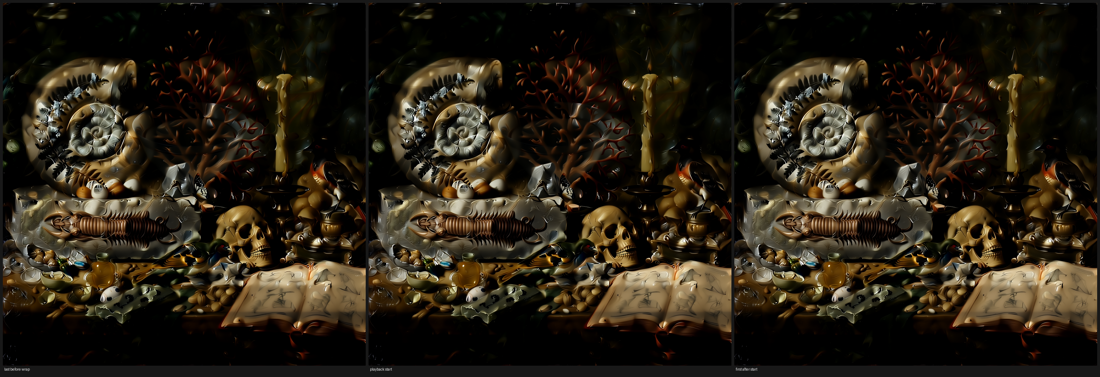

### Generated-image loop before RIFE

{'frames': 528, 'cut_index': 189, 'seam_vs_median': 0.4669, 'motion_mismatch': 0.002962, 'preview_video': '/content/drive/MyDrive/FluxFlowMorphArt/science_path_recursive_flowmorph/science_path_recursive_flowmorph_0008_20260722T111308Z/previews/generated_loop/generated_loop_reduced.mp4'}


In [ ]:
import json
import imageio_ffmpeg
import numpy as np
import shutil
import subprocess
import tempfile
from pathlib import Path
from PIL import Image
from IPython.display import Markdown, Video, display
from flowmorph_klein.visualization import make_contact_sheet

# A Colab reconnect clears Python variables while completed manifests and
# images remain on Drive. Recover the final sequence before auditing it.
if "FINAL_RECORDS" not in globals():
    if "RUN_DIRECTORY" not in globals():
        raise RuntimeError(
            "RUN_DIRECTORY is not initialized. Set RESUME_RUN_DIRECTORY to the "
            "completed Drive run, then rerun the setup cells before section 10."
        )
    restored_manifest_candidates = []
    explicit_manifest = globals().get("FINAL_SEQUENCE_MANIFEST")
    if explicit_manifest:
        restored_manifest_candidates.append(Path(explicit_manifest))
    restored_manifest_candidates.extend([
        RUN_DIRECTORY / "metadata" / "final_recursive_flowmorph_sequence.json",
        RUN_DIRECTORY / "metadata" / "final_recursive_sequence.json",
    ])
    restored_manifest_path = next(
        (path for path in restored_manifest_candidates if path.is_file()),
        None,
    )
    if restored_manifest_path is None:
        discovered_manifests = sorted(
            [
                *RUN_DIRECTORY.parent.glob(
                    "*/metadata/final_recursive_flowmorph_sequence.json"
                ),
                *RUN_DIRECTORY.parent.glob("*/metadata/final_recursive_sequence.json"),
            ],
            key=lambda path: path.stat().st_mtime,
            reverse=True,
        )
        discovery_note = (
            " Completed manifests in sibling runs: "
            + ", ".join(str(path.parent.parent) for path in discovered_manifests[:5])
            if discovered_manifests
            else " No completed sibling-run manifest was found."
        )
        raise RuntimeError(
            "FINAL_RECORDS is not in memory and the saved sequence manifest was "
            f"not found in {RUN_DIRECTORY / 'metadata'}. Set RESUME_RUN_DIRECTORY "
            "to the completed Drive run and rerun the setup cells." + discovery_note
        )
    restored_payload = json.loads(restored_manifest_path.read_text(encoding="utf-8"))
    FINAL_RECORDS = restored_payload["records"]
    FINAL_SEQUENCE_MANIFEST = restored_manifest_path
    print({
        "restored_final_sequence": True,
        "frames": len(FINAL_RECORDS),
        "manifest": str(FINAL_SEQUENCE_MANIFEST),
    })

if len(FINAL_RECORDS) < 3:
    raise RuntimeError("A cyclic preview needs at least three images")
if LOOP_PREVIEW_RENDER_MAX_SIDE < 128:
    raise ValueError("LOOP_PREVIEW_RENDER_MAX_SIDE must be at least 128")

canonical_paths = [Path(item["path"]) for item in FINAL_RECORDS]

def metric_array(path, size):
    with Image.open(path) as opened:
        sample = opened.convert("RGB")
        sample.thumbnail((size, size))
        return np.asarray(sample, dtype=np.uint8).copy()

def mean_absolute_delta(left, right):
    difference = left.astype(np.int16) - right.astype(np.int16)
    return float(np.mean(np.abs(difference)) / 255.0)

print(f"Reading {len(canonical_paths)} small seam-analysis thumbnails (not full frames)...")
metric_frames = [metric_array(path, LOOP_SEAM_ANALYSIS_SIZE) for path in canonical_paths]
edge_scores = [
    mean_absolute_delta(metric_frames[index], metric_frames[index - 1])
    for index in range(len(metric_frames))
]
quietest_cut_index = int(np.argmin(edge_scores))
export_cut_index = quietest_cut_index if LOOP_AUTO_ROTATE_TO_QUIETEST_CUT else 0
EXPORT_FRAME_PATHS = canonical_paths[export_cut_index:] + canonical_paths[:export_cut_index]
EXPORT_RECORDS = FINAL_RECORDS[export_cut_index:] + FINAL_RECORDS[:export_cut_index]
export_metrics = metric_frames[export_cut_index:] + metric_frames[:export_cut_index]

seam_delta = mean_absolute_delta(export_metrics[0], export_metrics[-1])
median_delta = float(np.median(edge_scores))
seam_ratio = seam_delta / median_delta if median_delta else 0.0
incoming_motion = export_metrics[0].astype(np.int16) - export_metrics[-1].astype(np.int16)
outgoing_motion = export_metrics[1].astype(np.int16) - export_metrics[0].astype(np.int16)
motion_mismatch = float(np.mean(np.abs(outgoing_motion - incoming_motion)) / 255.0)

preview_directory = RUN_DIRECTORY / "previews" / "generated_loop"
preview_directory.mkdir(parents=True, exist_ok=True)
preview_video_path = preview_directory / "generated_loop_reduced.mp4"
preview_stage = Path(tempfile.mkdtemp(prefix="flowmorph_preview_"))
try:
    for index, source_path in enumerate(EXPORT_FRAME_PATHS):
        staged_path = preview_stage / f"{index:07d}.png"
        try:
            staged_path.symlink_to(source_path.resolve())
        except OSError:
            shutil.copy2(source_path, staged_path)
    ffmpeg = imageio_ffmpeg.get_ffmpeg_exe()
    subprocess.check_call([
        ffmpeg, "-y", "-framerate", str(SOURCE_SEQUENCE_FPS),
        "-i", str(preview_stage / "%07d.png"),
        "-vf", (
            f"scale={LOOP_PREVIEW_RENDER_MAX_SIDE}:{LOOP_PREVIEW_RENDER_MAX_SIDE}:"
            "force_original_aspect_ratio=decrease:force_divisible_by=2"
        ),
        "-an", "-c:v", "libx264", "-preset", "veryfast",
        "-crf", "22", "-pix_fmt", "yuv420p", "-movflags", "+faststart",
        str(preview_video_path),
    ])
finally:
    shutil.rmtree(preview_stage, ignore_errors=True)

seam_sheet_path = preview_directory / "seam_audit.png"
seam_images = []
try:
    for path in (EXPORT_FRAME_PATHS[-1], EXPORT_FRAME_PATHS[0], EXPORT_FRAME_PATHS[1]):
        with Image.open(path) as opened:
            seam_images.append(opened.convert("RGB"))
    make_contact_sheet(
        seam_images,
        seam_sheet_path,
        columns=3,
        labels=["last before wrap", "playback start", "first after start"],
    )
finally:
    for image in seam_images:
        image.close()
seam_report = {
    "cyclic": True,
    "duplicate_terminal_frame": False,
    "frame_count": len(EXPORT_FRAME_PATHS),
    "auto_rotate": LOOP_AUTO_ROTATE_TO_QUIETEST_CUT,
    "cut_index": export_cut_index,
    "quietest_cut_index": quietest_cut_index,
    "seam_mean_absolute_delta": seam_delta,
    "median_edge_mean_absolute_delta": median_delta,
    "seam_ratio_to_median": seam_ratio,
    "seam_motion_mismatch": motion_mismatch,
    "ordered_uids": [item["uid"] for item in EXPORT_RECORDS],
}
seam_report_path = preview_directory / "seam_audit.json"
seam_report_path.write_text(json.dumps(seam_report, indent=2) + "\n", encoding="utf-8")

seam_preview = Image.open(seam_sheet_path).convert("RGB")
seam_preview.thumbnail((CONTACT_SHEET_DISPLAY_MAX_WIDTH, 100000))
display(Markdown("### Loop seam: last → playback start → next"))
display(seam_preview)
del seam_preview
display(Markdown("### Generated-image loop before RIFE"))
display(Video(
    str(preview_video_path),
    embed=False,
    width=LOOP_PREVIEW_DISPLAY_WIDTH,
    html_attributes="controls loop muted playsinline",
))
del metric_frames, export_metrics, incoming_motion, outgoing_motion
print({
    "frames": len(EXPORT_FRAME_PATHS),
    "cut_index": export_cut_index,
    "seam_vs_median": round(seam_ratio, 4),
    "motion_mismatch": round(motion_mismatch, 6),
    "preview_video": str(preview_video_path),
})


## 11. Prepare pinned Practical-RIFE and its v4.25 model

RIFE operates on the lossless generated PNG sequence, including a final-to-first pair. Its large temporary dense-frame lattice stays on local Colab storage; only diagnostics and the final video are written to the persistent run directory.


In [26]:
import subprocess
import zipfile

if not RUN_RIFE_POSTPROCESS:
    print("RIFE post-processing disabled in section 1.")
else:
    if not torch.cuda.is_available():
        raise RuntimeError("RIFE requires CUDA")
    if RIFE_MULTIPLIER < 2:
        raise ValueError("RIFE_MULTIPLIER must be at least 2")
    if RIFE_BATCH_SIZE < 1:
        raise ValueError("RIFE_BATCH_SIZE must be positive")
    if RIFE_SCALE not in {0.25, 0.5, 1.0, 2.0, 4.0}:
        raise ValueError("RIFE_SCALE must be 0.25, 0.5, 1.0, 2.0, or 4.0")
    if RIFE_FINAL_FPS <= 0 or SOURCE_SEQUENCE_FPS <= 0:
        raise ValueError("Source and final FPS must be positive")
    if RIFE_FINAL_FPS / SOURCE_SEQUENCE_FPS > RIFE_MULTIPLIER:
        raise ValueError("RIFE_MULTIPLIER must be at least RIFE_FINAL_FPS / SOURCE_SEQUENCE_FPS")

    rife_root = Path(RIFE_ROOT)
    if not (rife_root / ".git").is_dir():
        if rife_root.exists():
            raise RuntimeError(f"RIFE_ROOT exists but is not a Git checkout: {rife_root}")
        subprocess.check_call(["git", "clone", "--filter=blob:none", RIFE_REPOSITORY_URL, str(rife_root)])
    installed_revision = subprocess.check_output(
        ["git", "-C", str(rife_root), "rev-parse", "HEAD"], text=True
    ).strip()
    if installed_revision != RIFE_REPOSITORY_REVISION:
        subprocess.check_call([
            "git", "-C", str(rife_root), "fetch", "--depth", "1",
            "origin", RIFE_REPOSITORY_REVISION,
        ])
        subprocess.check_call([
            "git", "-C", str(rife_root), "checkout", "--detach", RIFE_REPOSITORY_REVISION
        ])
    installed_revision = subprocess.check_output(
        ["git", "-C", str(rife_root), "rev-parse", "HEAD"], text=True
    ).strip()
    if installed_revision != RIFE_REPOSITORY_REVISION:
        raise RuntimeError("Practical-RIFE checkout did not resolve to the pinned revision")

    rife_archive = Path(hf_hub_download(
        repo_id=RIFE_MODEL_REPOSITORY,
        filename=RIFE_MODEL_FILENAME,
        revision=RIFE_MODEL_REVISION,
        cache_dir=HF_CACHE_DIR,
    ))
    rife_model_root = Path(HF_CACHE_DIR) / "flowmorph_rife_models" / RIFE_MODEL_FILENAME.removesuffix(".zip")
    candidates = list(rife_model_root.rglob("flownet.pkl")) if rife_model_root.exists() else []
    if not candidates:
        rife_model_root.mkdir(parents=True, exist_ok=True)
        root_resolved = rife_model_root.resolve()
        with zipfile.ZipFile(rife_archive) as archive:
            for member in archive.infolist():
                destination = (rife_model_root / member.filename).resolve()
                if not destination.is_relative_to(root_resolved):
                    raise RuntimeError(f"Unsafe path in RIFE archive: {member.filename}")
            archive.extractall(rife_model_root)
        candidates = list(rife_model_root.rglob("flownet.pkl"))
    if len(candidates) != 1:
        raise RuntimeError(f"Expected one RIFE flownet.pkl, found {candidates}")
    RIFE_MODEL_DIRECTORY = candidates[0].parent

    RIFE_RUNNER_SOURCE = r'''
import argparse
import shutil
import sys
from pathlib import Path

import numpy as np
import torch
import torch.nn.functional as F
from PIL import Image

parser = argparse.ArgumentParser()
parser.add_argument("--repo", required=True)
parser.add_argument("--model", required=True)
parser.add_argument("--input", required=True)
parser.add_argument("--output", required=True)
parser.add_argument("--multi", type=int, required=True)
parser.add_argument("--scale", type=float, required=True)
parser.add_argument("--batch-size", type=int, default=1)
parser.add_argument("--fp16", action="store_true")
args = parser.parse_args()

if not torch.cuda.is_available():
    raise RuntimeError("CUDA is required for RIFE")
if args.batch_size < 1:
    raise ValueError("--batch-size must be positive")
torch.cuda.set_device(0)
device = torch.device("cuda:0")
sys.path.insert(0, str(Path(args.model).resolve().parent))
sys.path.insert(0, str(Path(args.repo).resolve()))
import train_log.IFNet_HDv3 as rife_ifnet_module
from train_log.IFNet_HDv3 import IFNet

# Practical-RIFE's pinned warplayer builds its cached sampling grid in
# float32. torch.grid_sample requires input and grid to share a dtype,
# so that implementation fails when the network runs in fp16. Replace
# the function in IFNet's module namespace with a device/dtype-aware
# equivalent while retaining the pinned model and weights.
rife_grid_cache = {}

def dtype_safe_warp(tensor_input, tensor_flow):
    cache_key = (
        str(tensor_flow.device),
        str(tensor_flow.dtype),
        tuple(tensor_flow.shape),
    )
    if cache_key not in rife_grid_cache:
        horizontal = torch.linspace(
            -1.0, 1.0, tensor_flow.shape[3],
            device=tensor_flow.device, dtype=tensor_flow.dtype,
        ).view(1, 1, 1, tensor_flow.shape[3]).expand(
            tensor_flow.shape[0], -1, tensor_flow.shape[2], -1
        )
        vertical = torch.linspace(
            -1.0, 1.0, tensor_flow.shape[2],
            device=tensor_flow.device, dtype=tensor_flow.dtype,
        ).view(1, 1, tensor_flow.shape[2], 1).expand(
            tensor_flow.shape[0], -1, -1, tensor_flow.shape[3]
        )
        rife_grid_cache[cache_key] = torch.cat((horizontal, vertical), dim=1)
    normalized_flow = torch.cat((
        tensor_flow[:, 0:1] / ((tensor_input.shape[3] - 1.0) / 2.0),
        tensor_flow[:, 1:2] / ((tensor_input.shape[2] - 1.0) / 2.0),
    ), dim=1)
    grid = (rife_grid_cache[cache_key] + normalized_flow).permute(0, 2, 3, 1)
    return F.grid_sample(
        tensor_input,
        grid,
        mode="bilinear",
        padding_mode="border",
        align_corners=True,
    )

rife_ifnet_module.warp = dtype_safe_warp

input_paths = sorted(Path(args.input).glob("*.png"), key=lambda path: int(path.stem))
if len(input_paths) < 2:
    raise ValueError("RIFE input needs at least two numbered PNG files")
output = Path(args.output)
output.mkdir(parents=True, exist_ok=False)

class InferenceModel:
    def __init__(self, model_directory):
        # Load on CPU first, then move the complete initialized module to
        # one explicit CUDA device. This avoids mixed CPU/CUDA parameters
        # with newer torch/checkpoint combinations.
        self.flownet = IFNet()
        state = torch.load(
            str(Path(model_directory) / "flownet.pkl"), map_location="cpu", weights_only=True
        )
        state = {key.removeprefix("module."): value for key, value in state.items()}
        load_result = self.flownet.load_state_dict(state, strict=False)
        if load_result.missing_keys:
            raise RuntimeError(f"RIFE checkpoint missing keys: {load_result.missing_keys}")
        self.flownet.to(device).eval()

    def inference(self, image0, image1, timestep, scale):
        inputs = torch.cat((image0, image1), dim=1)
        scale_list = [16 / scale, 8 / scale, 4 / scale, 2 / scale, 1 / scale]
        _, _, merged = self.flownet(inputs, timestep, scale_list)
        return merged[-1]

model = InferenceModel(args.model)
if args.fp16:
    model.flownet.half()
model_dtype = next(model.flownet.parameters()).dtype
model_device = next(model.flownet.parameters()).device
if model_device != device:
    raise RuntimeError(f"RIFE model resolved to {model_device}, expected {device}")
print({
    "cuda_device": torch.cuda.get_device_name(device),
    "torch": torch.__version__,
    "model_device": str(model_device),
    "model_dtype": str(model_dtype),
    "input_pairs": len(input_paths) - 1,
}, flush=True)
first_image = Image.open(input_paths[0]).convert("RGB")
height, width = first_image.height, first_image.width
block = max(128, int(128 / args.scale))
padded_height = ((height - 1) // block + 1) * block
padded_width = ((width - 1) // block + 1) * block
padding = (0, padded_width - width, 0, padded_height - height)

def load_tensor(path):
    image = Image.open(path).convert("RGB")
    if image.size != (width, height):
        raise ValueError(f"Mismatched input dimensions at {path}: {image.size}")
    array = np.asarray(image, dtype=np.uint8).copy()
    tensor = torch.from_numpy(array.transpose(2, 0, 1)).unsqueeze(0)
    tensor = tensor.to(device=device, dtype=model_dtype) / 255.0
    return F.pad(tensor, padding)

def save_tensor(tensor, path):
    if tensor.shape[0] != 1:
        raise ValueError("save_tensor expects one image")
    array = (tensor[0, :, :height, :width].float().clamp(0, 1) * 255.0).round().byte()
    array = array.permute(1, 2, 0).cpu().numpy()
    Image.fromarray(array, mode="RGB").save(path, compress_level=4)

pair_count = len(input_paths) - 1
shutil.copy2(input_paths[0], output / "0000000.png")
report_every = max(1, pair_count // 20)
pair_start = 0
active_batch_size = min(args.batch_size, pair_count)
with torch.inference_mode():
    while pair_start < pair_count:
        current_size = min(active_batch_size, pair_count - pair_start)
        pair_indices = list(range(pair_start, pair_start + current_size))
        left = None
        right = None
        try:
            left = torch.cat(
                [load_tensor(input_paths[index]) for index in pair_indices],
                dim=0,
            )
            right = torch.cat(
                [load_tensor(input_paths[index + 1]) for index in pair_indices],
                dim=0,
            )
            for step in range(1, args.multi):
                middle = model.inference(
                    left,
                    right,
                    timestep=step / args.multi,
                    scale=args.scale,
                )
                for offset, pair_index in enumerate(pair_indices):
                    output_index = pair_index * args.multi + step
                    save_tensor(
                        middle[offset : offset + 1],
                        output / f"{output_index:07d}.png",
                    )
            for pair_index in pair_indices:
                output_index = (pair_index + 1) * args.multi
                shutil.copy2(
                    input_paths[pair_index + 1],
                    output / f"{output_index:07d}.png",
                )
        except torch.cuda.OutOfMemoryError:
            if current_size == 1:
                raise
            active_batch_size = max(1, (current_size + 1) // 2)
            del left, right
            torch.cuda.empty_cache()
            print(
                f"RIFE OOM; retrying pair batch with batch_size={active_batch_size}",
                flush=True,
            )
            continue
        pair_start += current_size
        if pair_start % report_every == 0 or pair_start == pair_count:
            print(
                f"RIFE pairs: {pair_start}/{pair_count}; "
                f"active_batch_size={active_batch_size}",
                flush=True,
            )
output_count = pair_count * args.multi + 1
print(f"RIFE complete: {output_count} PNG frames")
'''
    RIFE_RUNNER_PATH = Path(LOCAL_ASSET_ROOT) / PROJECT_NAME / "rife_pair_sequence_runner.py"
    RIFE_RUNNER_PATH.parent.mkdir(parents=True, exist_ok=True)
    RIFE_RUNNER_PATH.write_text(RIFE_RUNNER_SOURCE.strip() + "\n", encoding="utf-8")
    print({
        "rife_revision": installed_revision,
        "model_directory": str(RIFE_MODEL_DIRECTORY),
        "multiplier": RIFE_MULTIPLIER,
        "scale": RIFE_SCALE,
        "batch_size": RIFE_BATCH_SIZE,
        "runner": str(RIFE_RUNNER_PATH),
    })


NameError: name 'hf_hub_download' is not defined

## 12. Interpolate the circular PNG sequence with RIFE

The opening image is appended once as a temporary terminal input so RIFE explicitly processes the wraparound pair. The exact duplicate is verified and removed before resampling and export.


In [ ]:
if RUN_RIFE_POSTPROCESS:
    # A Colab reconnect clears Python variables even though completed images and
    # manifests remain on Drive. Restore the ordered export paths when needed.
    if "EXPORT_FRAME_PATHS" not in globals():
        restored_records = globals().get("FINAL_RECORDS")
        if not restored_records:
            restored_manifest_candidates = []
            explicit_manifest = globals().get("FINAL_SEQUENCE_MANIFEST")
            if explicit_manifest:
                restored_manifest_candidates.append(Path(explicit_manifest))
            restored_manifest_candidates.extend([
                RUN_DIRECTORY / "metadata" / "final_recursive_flowmorph_sequence.json",
                RUN_DIRECTORY / "metadata" / "final_recursive_sequence.json",
            ])
            restored_manifest_path = next(
                (path for path in restored_manifest_candidates if path.is_file()),
                None,
            )
            if restored_manifest_path is None:
                raise RuntimeError(
                    "The generated sequence is not available in memory and its saved "
                    f"manifest was not found in {RUN_DIRECTORY / 'metadata'}. Set "
                    "RESUME_RUN_DIRECTORY to the completed Drive run and rerun the "
                    "setup/assembly cells before RIFE."
                )
            restored_payload = json.loads(restored_manifest_path.read_text(encoding="utf-8"))
            restored_records = restored_payload["records"]

        restored_cut_index = 0
        restored_seam_report_path = (
            RUN_DIRECTORY / "previews" / "generated_loop" / "seam_audit.json"
        )
        if restored_seam_report_path.is_file():
            restored_seam_report = json.loads(
                restored_seam_report_path.read_text(encoding="utf-8")
            )
            restored_cut_index = int(restored_seam_report.get("cut_index", 0))
        elif LOOP_AUTO_ROTATE_TO_QUIETEST_CUT:
            print(
                "No saved seam report was found; using canonical circular order. "
                "Run section 10 first if you want automatic quietest-cut rotation."
            )

        restored_cut_index %= len(restored_records)
        EXPORT_RECORDS = (
            restored_records[restored_cut_index:] + restored_records[:restored_cut_index]
        )
        EXPORT_FRAME_PATHS = [Path(item["path"]) for item in EXPORT_RECORDS]
        missing_export_paths = [path for path in EXPORT_FRAME_PATHS if not path.is_file()]
        if missing_export_paths:
            raise FileNotFoundError(
                "The restored sequence references missing image files; first missing path: "
                f"{missing_export_paths[0]}"
            )
        print({
            "restored_export_sequence": True,
            "frames": len(EXPORT_FRAME_PATHS),
            "cut_index": restored_cut_index,
        })

    postprocess_stamp = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%SZ")
    RIFE_WORK_DIRECTORY = Path(LOCAL_ASSET_ROOT) / PROJECT_NAME / "rife_work" / postprocess_stamp
    RIFE_INPUT_DIRECTORY = RIFE_WORK_DIRECTORY / "cyclic_input"
    RIFE_DENSE_DIRECTORY = RIFE_WORK_DIRECTORY / "dense_frames"
    RIFE_RESULTS_DIRECTORY = RUN_DIRECTORY / "video" / postprocess_stamp
    RIFE_INPUT_DIRECTORY.mkdir(parents=True, exist_ok=False)
    RIFE_RESULTS_DIRECTORY.mkdir(parents=True, exist_ok=False)

    for index, source_path in enumerate(EXPORT_FRAME_PATHS):
        shutil.copy2(source_path, RIFE_INPUT_DIRECTORY / f"{index:07d}.png")
    shutil.copy2(
        RIFE_INPUT_DIRECTORY / "0000000.png",
        RIFE_INPUT_DIRECTORY / f"{len(EXPORT_FRAME_PATHS):07d}.png",
    )
    command = [
        sys.executable, "-u", str(RIFE_RUNNER_PATH),
        "--repo", str(rife_root),
        "--model", str(RIFE_MODEL_DIRECTORY),
        "--input", str(RIFE_INPUT_DIRECTORY),
        "--output", str(RIFE_DENSE_DIRECTORY),
        "--multi", str(RIFE_MULTIPLIER),
        "--scale", str(RIFE_SCALE),
        "--batch-size", str(RIFE_BATCH_SIZE),
    ]
    if RIFE_USE_FP16:
        command.append("--fp16")
    print(f"Interpolating {len(EXPORT_FRAME_PATHS)} cyclic pairs at {RIFE_MULTIPLIER}× density...")

    def run_rife(command_to_run, label):
        print(f"RIFE attempt: {label}", flush=True)
        process = subprocess.Popen(
            command_to_run,
            stdout=subprocess.PIPE,
            stderr=subprocess.STDOUT,
            text=True,
            bufsize=1,
        )
        log_lines = []
        assert process.stdout is not None
        for line in process.stdout:
            log_lines.append(line)
            print(line, end="", flush=True)
        return_code = process.wait()
        log_text = "".join(log_lines) or "(RIFE produced no subprocess output)"
        if not log_lines:
            print(log_text)
        return return_code, log_text

    return_code, rife_log = run_rife(
        command,
        "fp16" if "--fp16" in command else "fp32",
    )
    if return_code != 0 and "--fp16" in command and RIFE_RETRY_WITH_FP32:
        print("The fp16 RIFE attempt failed; retrying once in fp32.")
        RIFE_DENSE_DIRECTORY = RIFE_WORK_DIRECTORY / "dense_frames_fp32_retry"
        retry_command = [item for item in command if item != "--fp16"]
        output_index = retry_command.index("--output") + 1
        retry_command[output_index] = str(RIFE_DENSE_DIRECTORY)
        return_code, rife_log = run_rife(retry_command, "fp32 fallback")
    if return_code != 0:
        raise RuntimeError(
            "RIFE failed after the available attempt(s). The complete child-process "
            "traceback is printed immediately above. Last output:\n" + rife_log[-6000:]
        )

    dense_with_duplicate = sorted(
        RIFE_DENSE_DIRECTORY.glob("*.png"), key=lambda path: int(path.stem)
    )
    expected = len(EXPORT_FRAME_PATHS) * RIFE_MULTIPLIER + 1
    if len(dense_with_duplicate) != expected:
        raise RuntimeError(f"RIFE wrote {len(dense_with_duplicate)} frames; expected {expected}")
    with Image.open(dense_with_duplicate[0]) as opened:
        first_array = np.asarray(opened.convert("RGB"))
    with Image.open(dense_with_duplicate[-1]) as opened:
        last_array = np.asarray(opened.convert("RGB"))
    if not np.array_equal(first_array, last_array):
        raise RuntimeError("RIFE terminal image is not pixel-identical to the opening image")
    RIFE_DENSE_PATHS = dense_with_duplicate[:-1]
    print({
        "base_cyclic_frames": len(EXPORT_FRAME_PATHS),
        "dense_unique_frames": len(RIFE_DENSE_PATHS),
        "removed_exact_terminal_duplicate": True,
        "local_work_directory": str(RIFE_WORK_DIRECTORY),
        "persistent_results_directory": str(RIFE_RESULTS_DIRECTORY),
    })


## 13. Circular SSIM motion equalization and final H.264 loop

Dense RIFE frames are weighted by circular `1 − SSIM`. Monotonic unique selection places more final frames where visual motion is larger while preserving duration and the cyclic wrap. The MP4, report, and motion plot are written directly to Drive; large temporary PNG lattices are deleted only after successful export when `RIFE_KEEP_WORK_FRAMES=False`.


In [ ]:
if RUN_RIFE_POSTPROCESS:
    import imageio_ffmpeg
    import matplotlib.pyplot as plt
    from IPython.display import Video
    from skimage.metrics import structural_similarity

    def ssim_luma(path):
        with Image.open(path) as opened:
            gray = opened.convert("L")
            gray.thumbnail((RIFE_SSIM_ANALYSIS_SIZE, RIFE_SSIM_ANALYSIS_SIZE))
            return np.asarray(gray, dtype=np.uint8)

    print(f"Computing circular SSIM weights for {len(RIFE_DENSE_PATHS)} dense frames...")
    dense_luma = [ssim_luma(path) for path in RIFE_DENSE_PATHS]
    circular_ssim = np.asarray([
        structural_similarity(dense_luma[index - 1], dense_luma[index], data_range=255)
        for index in range(len(dense_luma))
    ], dtype=np.float64)
    motion_weights = np.maximum(RIFE_SSIM_WEIGHT_FLOOR, 1.0 - circular_ssim)
    frame_positions = np.zeros(len(RIFE_DENSE_PATHS), dtype=np.float64)
    frame_positions[1:] = np.cumsum(motion_weights[1:])
    total_motion = float(frame_positions[-1] + motion_weights[0])

    canonical_duration = len(EXPORT_FRAME_PATHS) / float(SOURCE_SEQUENCE_FPS)
    target_frame_count = int(round(canonical_duration * RIFE_FINAL_FPS))
    if target_frame_count < 3:
        raise ValueError("Final video needs at least three frames")
    if target_frame_count > len(RIFE_DENSE_PATHS):
        raise ValueError("Increase RIFE_MULTIPLIER or lower RIFE_FINAL_FPS")
    targets = np.linspace(0.0, total_motion, target_frame_count, endpoint=False)

    selected_indices = []
    previous_index = -1
    dense_count = len(RIFE_DENSE_PATHS)
    for order, target in enumerate(targets):
        minimum = previous_index + 1
        maximum = dense_count - (target_frame_count - order)
        insertion = int(np.searchsorted(frame_positions, target, side="left"))
        candidates = {
            min(max(insertion, minimum), maximum),
            min(max(insertion - 1, minimum), maximum),
        }
        chosen = min(candidates, key=lambda index: abs(frame_positions[index] - target))
        selected_indices.append(chosen)
        previous_index = chosen
    selected_indices[0] = 0
    selected_indices[-1] = dense_count - 1
    if len(set(selected_indices)) != target_frame_count:
        raise RuntimeError("SSIM resampling produced duplicate selections")

    selected_directory = RIFE_WORK_DIRECTORY / "ssim_resampled_frames"
    selected_directory.mkdir(parents=True, exist_ok=True)
    # This is a generated, run-local staging directory. Clear numbered
    # frames so rerunning this cell cannot leave stale PNGs behind when
    # timing settings or the selected frame count change.
    for stale_frame in selected_directory.glob("*.png"):
        stale_frame.unlink()
    for output_index, dense_index in enumerate(selected_indices):
        source = RIFE_DENSE_PATHS[dense_index]
        destination = selected_directory / f"{output_index:07d}.png"
        try:
            os.link(source, destination)
        except OSError:
            shutil.copy2(source, destination)

    RIFE_FINAL_VIDEO_PATH = RIFE_RESULTS_DIRECTORY / "recursive_flowmorph_vision_rife_ssim_loop.mp4"
    ffmpeg = imageio_ffmpeg.get_ffmpeg_exe()
    subprocess.check_call([
        ffmpeg, "-y", "-framerate", str(RIFE_FINAL_FPS),
        "-i", str(selected_directory / "%07d.png"),
        "-an", "-c:v", "libx264", "-preset", "slow",
        "-crf", str(RIFE_VIDEO_CRF), "-pix_fmt", "yuv420p",
        "-movflags", "+faststart", str(RIFE_FINAL_VIDEO_PATH),
    ])
    if not RIFE_FINAL_VIDEO_PATH.is_file() or RIFE_FINAL_VIDEO_PATH.stat().st_size == 0:
        raise RuntimeError("FFmpeg did not create the final video")

    selected_ssim = np.asarray([
        structural_similarity(
            dense_luma[selected_indices[index - 1]],
            dense_luma[selected_indices[index]],
            data_range=255,
        )
        for index in range(target_frame_count)
    ], dtype=np.float64)
    selected_motion = 1.0 - selected_ssim
    report = {
        "method": "cyclic PNGs -> Practical-RIFE -> circular 1-SSIM equal-motion sampling -> H.264",
        "rife_repository": RIFE_REPOSITORY_URL,
        "rife_revision": RIFE_REPOSITORY_REVISION,
        "rife_model_repository": RIFE_MODEL_REPOSITORY,
        "rife_model_revision": RIFE_MODEL_REVISION,
        "rife_model_filename": RIFE_MODEL_FILENAME,
        "rife_multiplier": RIFE_MULTIPLIER,
        "rife_batch_size": RIFE_BATCH_SIZE,
        "rife_scale": RIFE_SCALE,
        "rife_fp16": RIFE_USE_FP16,
        "base_frames": len(EXPORT_FRAME_PATHS),
        "dense_unique_frames": len(RIFE_DENSE_PATHS),
        "final_unique_frames": target_frame_count,
        "source_fps": SOURCE_SEQUENCE_FPS,
        "final_fps": RIFE_FINAL_FPS,
        "duration_seconds": target_frame_count / RIFE_FINAL_FPS,
        "dense_ssim": {
            "mean": float(circular_ssim.mean()),
            "median": float(np.median(circular_ssim)),
            "minimum": float(circular_ssim.min()),
            "wraparound": float(circular_ssim[0]),
        },
        "resampled_ssim": {
            "mean": float(selected_ssim.mean()),
            "median": float(np.median(selected_ssim)),
            "minimum": float(selected_ssim.min()),
            "wraparound": float(selected_ssim[0]),
            "motion_coefficient_of_variation": (
                float(selected_motion.std() / selected_motion.mean())
                if selected_motion.mean() else 0.0
            ),
        },
        "selected_dense_indices": selected_indices,
        "terminal_duplicate_in_video": False,
        "video": str(RIFE_FINAL_VIDEO_PATH),
    }
    RIFE_REPORT_PATH = RIFE_RESULTS_DIRECTORY / "rife_ssim_report.json"
    RIFE_REPORT_PATH.write_text(
        json.dumps(report, indent=2, ensure_ascii=False) + "\n", encoding="utf-8"
    )

    RIFE_SSIM_PLOT_PATH = RIFE_RESULTS_DIRECTORY / "ssim_motion_profile.png"
    figure, axes = plt.subplots(2, 1, figsize=(12, 5), constrained_layout=True)
    axes[0].plot(motion_weights, linewidth=0.7, color="#4b6a88")
    axes[0].scatter([0], [motion_weights[0]], color="#c43d32", s=24, label="wrap edge")
    axes[0].set_title("Dense RIFE motion profile (1 − circular SSIM)")
    axes[0].legend(loc="upper right")
    axes[1].plot(selected_motion, linewidth=0.8, color="#7a5535")
    axes[1].scatter([0], [selected_motion[0]], color="#c43d32", s=24, label="wrap edge")
    axes[1].set_title("After equal-motion resampling")
    axes[1].set_xlabel("Frame edge")
    axes[1].legend(loc="upper right")
    for axis in axes:
        axis.set_ylabel("1 − SSIM")
        axis.grid(alpha=0.2)
    figure.savefig(RIFE_SSIM_PLOT_PATH, dpi=160, facecolor="white")
    plt.close(figure)

    plot_preview = Image.open(RIFE_SSIM_PLOT_PATH).convert("RGB")
    plot_preview.thumbnail((CONTACT_SHEET_DISPLAY_MAX_WIDTH, 100000))
    display(Markdown("### Final RIFE + circular SSIM diagnostics"))
    display(plot_preview)
    del plot_preview
    display(Video(
        str(RIFE_FINAL_VIDEO_PATH),
        embed=False,
        width=RIFE_DISPLAY_WIDTH,
        html_attributes="controls loop muted playsinline",
    ))
    print({
        "final_video": str(RIFE_FINAL_VIDEO_PATH),
        "frames": target_frame_count,
        "fps": RIFE_FINAL_FPS,
        "seconds": round(target_frame_count / RIFE_FINAL_FPS, 3),
        "wraparound_ssim": round(float(selected_ssim[0]), 6),
        "motion_variation": round(report["resampled_ssim"]["motion_coefficient_of_variation"], 6),
    })

    if DOWNLOAD_FINAL_VIDEO:
        try:
            from google.colab import files
        except ImportError:
            print("Colab download helper unavailable; use the printed video path.")
        else:
            files.download(str(RIFE_FINAL_VIDEO_PATH))

    if not RIFE_KEEP_WORK_FRAMES:
        expected_parent = (Path(LOCAL_ASSET_ROOT) / PROJECT_NAME / "rife_work").resolve()
        target = RIFE_WORK_DIRECTORY.resolve()
        if target.parent != expected_parent:
            raise RuntimeError(f"Refusing to remove unexpected RIFE directory: {target}")
        shutil.rmtree(target)
        print("Removed temporary local RIFE PNGs after successful persistent export.")
